# VíaSegura AI — Notebook 03
## Validación de actualidad y enriquecimiento SIMUR

**Proyecto:** VíaSegura AI  
**Notebook:** 03  
**Periodo base de referencia:** 2016–2019  
**Objetivo:** Determinar si las zonas priorizadas en el periodo base mantienen relevancia con datos recientes, y explorar las capas complementarias del servicio SIMUR para preparar la integración de actores viales y vehículos en fases posteriores.

## Contexto

El Notebook 02 construyó el **Índice de Prioridad de Intervención (IPI)** sobre 260,831 siniestros del periodo 2016–2019. El IPI combina cinco componentes normalizados por rango percentil: volumen de siniestros, criticidad total, severidad promedio, persistencia temporal y fatalidad.

El resultado central del NB02 es un **Top 50 de zonas priorizadas** que concentra el 6.39 % de las muertes registradas en el periodo, siendo solo el 0.29 % del total de zonas analizadas.

Este notebook responde dos preguntas:
1. **¿Esas zonas siguen siendo relevantes con datos recientes?**
2. **¿Qué otras capas ofrece SIMUR para enriquecer el análisis?**

---

## Advertencia metodológica

> El IPI mide **prioridad exploratoria de intervención**, no riesgo vial real. Los resultados del periodo base no deben presentarse como diagnóstico actual de Bogotá. La comparación entre periodos es de **rankings relativos y presencia en cortes**, no de valores absolutos de IPI, porque cada IPI es un percentil interno a su propio conjunto de datos.

## Estructura del notebook

| Sección | Contenido | Descarga masiva |
|---|---|---|
| 1 | Introducción metodológica | No |
| 2 | Carga y validación de outputs del NB02 | No |
| 3 | Auditoría de datos recientes por año | Solo conteos (ligero) |
| 4 | Diagnóstico de integridad + decisión de periodo | No |
| **5** | **Descarga segura del periodo reciente** | **Sí — requiere `ANIOS_RECIENTES` definido** |
| 6 | Validación y conteos de la base reciente | No |
| 7 | Limpieza de la base reciente | No |
| 8 | Aplicación del IPI al periodo reciente | No |
| 9 | Comparación 2016–2019 vs periodo reciente | No |
| 10 | Clasificación de hotspots por persistencia | No |
| 11 | Exploración de capas hermanas SIMUR | Solo metadata (ligero) |
| 12 | Identificación de tablas para NB04 | No |
| 13 | Guardado de outputs | No |
| 14 | Resumen ejecutivo | No |

**Esta primera fase construye las Secciones 1–4 y la Sección 11.**  
La descarga masiva (Sección 5) requiere revisar la auditoría de la Sección 4 y definir `ANIOS_RECIENTES` manualmente.

## Convenciones de lenguaje

**Usar:** zonas priorizadas · zonas críticas · concentración de siniestros · criticidad · persistencia · prioridad exploratoria de intervención · hotspot persistente · hotspot emergente · hotspot de severidad/fatalidad

**Evitar:** «zonas más peligrosas» · «riesgo real» sin normalización por exposición · afirmaciones causales sin datos adicionales

**Umbrales de clasificación (parametrizados en la celda de parámetros globales):**

| Parámetro | Valor inicial | Significado |
|---|---|---|
| `TOP_PRIORIDAD_ALTA` | 50 | Zonas del periodo base consideradas de alta prioridad |
| `TOP_PERSISTENCIA` | 200 | Frontera para clasificar una zona como «persistente» en ambos periodos |
| `TOP_EMERGENTE` | 200 | Frontera para clasificar una zona como «emergente» en el periodo reciente |
| `TOP_SEGUIMIENTO` | 500 | Frontera para clasificar una zona base como «disminuida» |

> Estos umbrales son criterios exploratorios. Pueden ajustarse mediante análisis de sensibilidad en una fase posterior.

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import time
import json

try:
    import geopandas as gpd
    GEOPANDAS_OK = True
except ImportError:
    GEOPANDAS_OK = False
    print('⚠️  geopandas no disponible — se necesita para las Secciones 5–10.')

print('VíaSegura AI — Notebook 03 iniciado correctamente.')
if GEOPANDAS_OK:
    print('geopandas disponible ✅')

VíaSegura AI — Notebook 03 iniciado correctamente.
geopandas disponible ✅


In [2]:
# ============================================================
# PARÁMETROS GLOBALES
# Modificar aquí para análisis de sensibilidad
# ============================================================

URL_SIMUR    = 'https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer/2/query'
URL_SERVIDOR = 'https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer'

# --- Umbrales de clasificación de hotspots ---
# Estos valores son exploratorios — ver DECISIONS.md ADR-08
# Se pueden cambiar aquí para análisis de sensibilidad posterior
TOP_PRIORIDAD_ALTA = 50    # Umbral para «zona de alta prioridad» en el periodo base
TOP_PERSISTENCIA   = 200   # Zona presente en ambos periodos → «persistente»
TOP_EMERGENTE      = 200   # Solo en periodo reciente → «emergente»
TOP_SEGUIMIENTO    = 500   # En base pero fuera de este umbral en reciente → «disminuida»

# --- Periodo base ---
ANIOS_BASE   = [2016, 2017, 2018, 2019]
N_ANIOS_BASE = len(ANIOS_BASE)

# --- Años a auditar para el periodo reciente ---
ANIOS_A_AUDITAR = list(range(2020, 2026))

# --- Criterios mínimos de integridad ---
C_MIN_REGISTROS     = 15000  # Registros absolutos mínimos por año
C_MIN_PCT_BASE      = 0.20   # Al menos 20 % del promedio anual del periodo base
C_MIN_MESES         = 10     # Al menos 10 de 12 meses con datos
C_MAX_DESV_GRAVEDAD = 0.40   # Desviación máxima del ratio CON HERIDOS/SOLO DANOS vs base
C_MIN_LOCALIDADES   = 17     # Al menos 17 de 20 localidades con datos

# --- Localidades de Bogotá (tal como aparecen en la API SIMUR) ---
LOCALIDADES_BOGOTA = [
    'ANTONIO NARIÑO', 'BARRIOS UNIDOS', 'BOSA', 'CANDELARIA', 'CHAPINERO',
    'CIUDAD BOLIVAR', 'ENGATIVA', 'FONTIBON', 'KENNEDY', 'LOS MARTIRES',
    'PUENTE ARANDA', 'RAFAEL URIBE URIBE', 'SAN CRISTOBAL', 'SANTA FE',
    'SUBA', 'SUMAPAZ', 'TEUSAQUILLO', 'TUNJUELITO', 'USAQUEN', 'USME'
]

MESES = [
    'ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO',
    'JULIO', 'AGOSTO', 'SEPTIEMBRE', 'OCTUBRE', 'NOVIEMBRE', 'DICIEMBRE'
]

GRAVEDADES = ['SOLO DANOS', 'CON HERIDOS', 'CON MUERTOS']

print('Parámetros globales cargados.')
for k, v in [('TOP_PRIORIDAD_ALTA', TOP_PRIORIDAD_ALTA), ('TOP_PERSISTENCIA', TOP_PERSISTENCIA),
             ('TOP_EMERGENTE', TOP_EMERGENTE), ('TOP_SEGUIMIENTO', TOP_SEGUIMIENTO)]:
    print(f'  {k:<22} = {v}')

Parámetros globales cargados.
  TOP_PRIORIDAD_ALTA     = 50
  TOP_PERSISTENCIA       = 200
  TOP_EMERGENTE          = 200
  TOP_SEGUIMIENTO        = 500


---
## Sección 2 — Carga y validación de outputs del Notebook 02

Antes de cualquier consulta a SIMUR se verifica que los outputs del NB02 existen, tienen la forma esperada y sus estadísticas de referencia son consistentes.

In [3]:
import sys
from pathlib import Path

# Localizar config.py (compatible con VS Code, JupyterLab, cualquier cwd)
_root = next(
    (c for c in [Path.cwd(), Path.cwd().parent] if (c / 'config.py').exists()),
    None
)
if _root is None:
    raise RuntimeError(f"No se encontro config.py. cwd={Path.cwd()}")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from config import PROJECT_ROOT, DATA_RAW, DATA_PROCESSED, REPORTS, MAPS

# Alias para mantener compatibilidad con el resto del notebook
ruta_reports  = REPORTS
ruta_maps     = MAPS
ruta_data_raw = DATA_RAW
ruta_data_prc = DATA_PROCESSED   # usado en Secciones 5-9

# Rutas de outputs de NB02 (referencia cruzada entre notebooks)
archivos_nb02 = {
    'top50_base'   : REPORTS / 'top50_IPI_final_2016_2019.csv',
    'zonas_base'   : REPORTS / 'zonas_criticas_IPI_completo_2016_2019.csv',
    'familias_base': REPORTS / 'resumen_familia_analitica_2016_2019.csv',
    'concentracion': REPORTS / 'resumen_concentracion_IPI_2016_2019_final.csv',
}

print("Raiz del proyecto:", PROJECT_ROOT)
print("Reportes:         ", ruta_reports)
print("Datos procesados: ", ruta_data_prc)
print("Datos raw:        ", ruta_data_raw)
print()
print("Archivos NB02:")
for k, v in archivos_nb02.items():
    existe = v.exists()
    print(f"  {k}: {v.name} ({'OK' if existe else 'NO EXISTE'})")

Raiz del proyecto: C:\Users\jorge\Documents\viasegura_ai
Reportes:          C:\Users\jorge\Documents\viasegura_ai\outputs\reports
Datos procesados:  C:\Users\jorge\Documents\viasegura_ai\data\processed
Datos raw:         C:\Users\jorge\Documents\viasegura_ai\data\raw

Archivos NB02:
  top50_base: top50_IPI_final_2016_2019.csv (OK)
  zonas_base: zonas_criticas_IPI_completo_2016_2019.csv (OK)
  familias_base: resumen_familia_analitica_2016_2019.csv (OK)
  concentracion: resumen_concentracion_IPI_2016_2019_final.csv (OK)


In [4]:
top50_base    = pd.read_csv(archivos_nb02['top50_base'])
zonas_base    = pd.read_csv(archivos_nb02['zonas_base'])
familias_base = pd.read_csv(archivos_nb02['familias_base'])
concentracion = pd.read_csv(archivos_nb02['concentracion'])

# Validaciones de integridad
assert len(top50_base) == 50,             f'Top 50 esperado, encontrado: {len(top50_base)}'
assert 'IPI' in zonas_base.columns,       'Columna IPI no encontrada en zonas_base'
assert 'rank_IPI' in top50_base.columns,  'Columna rank_IPI no encontrada en top50_base'
assert top50_base['rank_IPI'].min() == 1, 'rank_IPI no empieza en 1'
assert top50_base['rank_IPI'].max() == 50,'rank_IPI no llega a 50'
assert 'top_n_zonas' in concentracion.columns

print(f'top50_base:    {len(top50_base)} filas × {top50_base.shape[1]} columnas')
print(f'zonas_base:    {len(zonas_base):,} filas × {zonas_base.shape[1]} columnas')
print(f'familias_base: {len(familias_base)} filas × {familias_base.shape[1]} columnas')
print(f'concentracion: {len(concentracion)} filas × {concentracion.shape[1]} columnas')
print('\nAserciones de integridad: OK ✅')

top50_base:    50 filas × 19 columnas
zonas_base:    17,130 filas × 36 columnas
familias_base: 5 filas × 6 columnas
concentracion: 4 filas × 8 columnas

Aserciones de integridad: OK ✅


ESTADÍSTICAS DE REFERENCIA — PERIODO BASE 2016-2019
  Zonas totales analizadas:      17,130
  Siniestros totales:           260,831
  Muertes registradas:            4,197
  Criticidad acumulada:         447,079
  IPI rango Top 50:             93.33 – 96.28
  % muertes en Top 50:            6.43%



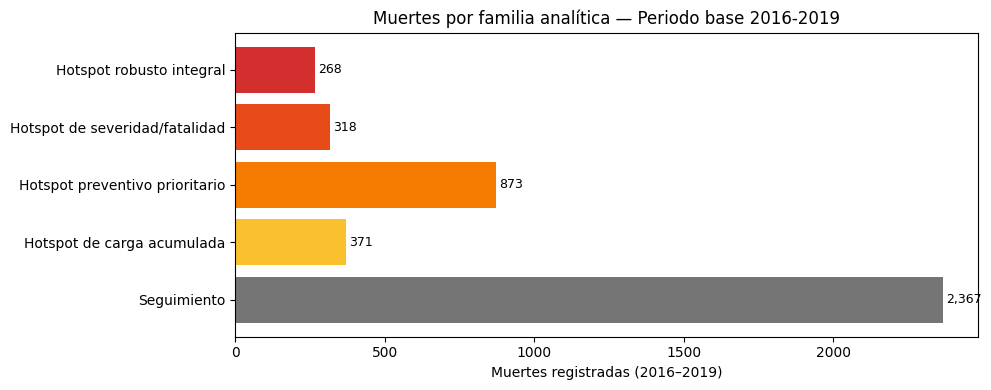

In [5]:
# Estadísticas de referencia del periodo base
total_sin  = int(zonas_base['cantidad_siniestros'].sum())
total_mts  = int(zonas_base['siniestros_con_muertos'].sum())
total_crit = int(zonas_base['criticidad_total'].sum())
n_zonas    = len(zonas_base)
ipi_min50  = top50_base['IPI'].min()
ipi_max50  = top50_base['IPI'].max()

row50 = concentracion[concentracion['top_n_zonas'] == TOP_PRIORIDAD_ALTA]
pct_mts50 = float(row50['porcentaje_siniestros_con_muertos'].values[0]) if len(row50) > 0 else 0.0

sep = '=' * 64
print(sep)
print('ESTADÍSTICAS DE REFERENCIA — PERIODO BASE 2016-2019')
print(sep)
print(f'  Zonas totales analizadas:  {n_zonas:>10,}')
print(f'  Siniestros totales:        {total_sin:>10,}')
print(f'  Muertes registradas:       {total_mts:>10,}')
print(f'  Criticidad acumulada:      {total_crit:>10,}')
print(f'  IPI rango Top {TOP_PRIORIDAD_ALTA}:          {ipi_min50:>8.2f} – {ipi_max50:.2f}')
print(f'  % muertes en Top {TOP_PRIORIDAD_ALTA}:       {pct_mts50:>9.2f}%')
print(sep)
print()

# Gráfico de barras de familias analíticas
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    familias_base['familia_analitica'],
    familias_base['muertes_registradas'],
    color=['#d32f2f','#e64a19','#f57c00','#fbc02d','#757575']
)
for bar, val in zip(bars, familias_base['muertes_registradas']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Muertes registradas (2016–2019)')
ax.set_title('Muertes por familia analítica — Periodo base 2016-2019')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Sección 3 — Auditoría de datos recientes por año

Antes de descargar cualquier dato masivo se audita la disponibilidad e integridad de los años recientes mediante **consultas ligeras** (`returnCountOnly=true`) al servidor SIMUR. Cada consulta devuelve solo un número, sin transmitir registros.

La auditoría tiene cuatro dimensiones:
1. **Conteo anual** — ¿cuántos registros hay por año?
2. **Cobertura mensual** — ¿tiene datos en los 12 meses?
3. **Distribución de GRAVEDAD** — ¿el ratio CON HERIDOS / SOLO DANOS es comparable al periodo base?
4. **Cobertura de localidades** — ¿aparecen las 20 localidades de Bogotá?

In [6]:
# Cargar auditoría del NB01 como punto de partida
ruta_audit_nb01 = ruta_reports / 'auditoria_conteo_siniestros_por_anio.csv'

if ruta_audit_nb01.exists():
    df_audit_nb01 = pd.read_csv(ruta_audit_nb01)
    promedio_base = df_audit_nb01[
        df_audit_nb01['anio'].isin(ANIOS_BASE)
    ]['cantidad_siniestros'].mean()
    print(f'Auditoría NB01 cargada: {len(df_audit_nb01)} años registrados')
    print(f'Promedio anual periodo base: {promedio_base:,.0f} siniestros/año')
    print()
    print('Conteos del NB01 para años relevantes:')
    df_vista = df_audit_nb01[df_audit_nb01['anio'] >= 2016].copy()
    df_vista['pct_del_base'] = (df_vista['cantidad_siniestros'] / promedio_base * 100).round(1)
    print(df_vista.to_string(index=False))
else:
    print('⚠️  Auditoría del NB01 no encontrada. Se ejecutará desde cero.')
    df_audit_nb01 = None
    promedio_base = 65208  # Promedio conocido del periodo base (NB01)

Auditoría NB01 cargada: 20 años registrados
Promedio anual periodo base: 64,957 siniestros/año

Conteos del NB01 para años relevantes:
 anio  cantidad_siniestros  pct_del_base
 2016                63655          98.0
 2017                64617          99.5
 2018                66531         102.4
 2019                65026         100.1
 2020                44049          67.8
 2021                28854          44.4
 2022                25446          39.2
 2023                14115          21.7
 2024                14018          21.6
 2025                12377          19.1
 2026                 2241           3.4


In [7]:
# Consulta fresca de conteos anuales 2020–2025
print('Consultando conteos actuales en SIMUR para años recientes...')
print('(Solo conteos — sin descarga de registros)\n')

conteos_frescos = []
for anio in ANIOS_A_AUDITAR:
    try:
        params = {'where': f'ANO_OCURRENCIA_ACC = {anio}',
                  'returnCountOnly': 'true', 'f': 'json'}
        r = requests.get(URL_SIMUR, params=params, timeout=30)
        count = int(r.json().get('count', 0))
        estado = '✅' if count >= C_MIN_REGISTROS else '⚠️ '
    except Exception as e:
        count = -1
        estado = '❌'
        print(f'  Error en {anio}: {e}')
    pct = count / promedio_base * 100 if count > 0 else 0
    barra = '█' * max(0, int(pct / 4))
    conteos_frescos.append({'anio': anio, 'cantidad_siniestros_actual': count, 'pct_del_promedio_base': round(pct, 1)})
    print(f'  {estado} {anio}: {count:>8,}  ({pct:>5.1f}% del promedio base)  |{barra}')
    time.sleep(0.5)

df_frescos = pd.DataFrame(conteos_frescos)
print()
print(f'Promedio anual base de referencia: {promedio_base:,.0f} siniestros/año')

Consultando conteos actuales en SIMUR para años recientes...
(Solo conteos — sin descarga de registros)



  ✅ 2020:   44,049  ( 67.8% del promedio base)  |████████████████


  ✅ 2021:   28,854  ( 44.4% del promedio base)  |███████████


  ✅ 2022:   25,446  ( 39.2% del promedio base)  |█████████


  ⚠️  2023:   14,115  ( 21.7% del promedio base)  |█████


  ⚠️  2024:   14,018  ( 21.6% del promedio base)  |█████


  ⚠️  2025:   12,377  ( 19.1% del promedio base)  |████



Promedio anual base de referencia: 64,957 siniestros/año


In [8]:
# Auditoría de cobertura mensual
print(f'Auditando cobertura mensual para {ANIOS_A_AUDITAR}...')
print(f'Estimado: {len(ANIOS_A_AUDITAR) * len(MESES)} consultas ligeras (~25–35 seg)\n')

cob_mensual = []
for anio in ANIOS_A_AUDITAR:
    meses_ok = 0
    detalle_meses = []
    for mes in MESES:
        try:
            params = {'where': f"ANO_OCURRENCIA_ACC = {anio} AND MES_OCURRENCIA_ACC = '{mes}'",
                      'returnCountOnly': 'true', 'f': 'json'}
            r = requests.get(URL_SIMUR, params=params, timeout=30)
            count = int(r.json().get('count', 0))
        except Exception:
            count = -1
        cob_mensual.append({'anio': anio, 'mes': mes, 'cantidad': count})
        if count > 0:
            meses_ok += 1
            detalle_meses.append(mes[:3])
        time.sleep(0.25)
    estado = '✅' if meses_ok >= C_MIN_MESES else '⚠️ '
    meses_str = ' '.join(detalle_meses) if detalle_meses else 'ninguno'
    print(f'  {estado} {anio}: {meses_ok:>2}/12 meses  →  {meses_str}')

df_cob_mensual = pd.DataFrame(cob_mensual)
print('\nAuditoría mensual completada.')

Auditando cobertura mensual para [2020, 2021, 2022, 2023, 2024, 2025]...
Estimado: 72 consultas ligeras (~25–35 seg)



  ✅ 2020: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC


  ✅ 2021: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC


  ✅ 2022: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC


  ✅ 2023: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC


  ✅ 2024: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC


  ✅ 2025: 12/12 meses  →  ENE FEB MAR ABR MAY JUN JUL AGO SEP OCT NOV DIC

Auditoría mensual completada.


In [9]:
# Auditoría de distribución de GRAVEDAD
anios_gravedad = ANIOS_BASE + ANIOS_A_AUDITAR
print(f'Auditando distribución de GRAVEDAD ({len(anios_gravedad)} años × {len(GRAVEDADES)} gravedades)...')
print(f'Estimado: {len(anios_gravedad) * len(GRAVEDADES)} consultas ligeras (~20–25 seg)\n')

ratios = []
for anio in anios_gravedad:
    cg = {}
    for g in GRAVEDADES:
        try:
            params = {'where': f"ANO_OCURRENCIA_ACC = {anio} AND GRAVEDAD = '{g}'",
                      'returnCountOnly': 'true', 'f': 'json'}
            r = requests.get(URL_SIMUR, params=params, timeout=30)
            cg[g] = int(r.json().get('count', 0))
        except Exception:
            cg[g] = 0
        time.sleep(0.25)
    total = sum(cg.values())
    if total > 0:
        ratio = cg['CON HERIDOS'] / max(cg['SOLO DANOS'], 1)
        ratios.append({
            'anio': anio, 'n_total': total,
            'n_solo_danos': cg['SOLO DANOS'],
            'n_con_heridos': cg['CON HERIDOS'],
            'n_con_muertos': cg['CON MUERTOS'],
            'pct_con_heridos': round(cg['CON HERIDOS'] / total * 100, 2),
            'pct_con_muertos': round(cg['CON MUERTOS'] / total * 100, 2),
            'ratio_heridos_danos': round(ratio, 4),
        })
        marca = '(BASE)' if anio in ANIOS_BASE else '      '
        print(f'  {anio} {marca}: total {total:>7,} | heridos {cg["CON HERIDOS"]:>6,} ({cg["CON HERIDOS"]/total*100:.1f}%) | muertos {cg["CON MUERTOS"]:>5,} | ratio {ratio:.3f}')

df_ratios = pd.DataFrame(ratios)
ratio_base_prom = df_ratios[df_ratios['anio'].isin(ANIOS_BASE)]['ratio_heridos_danos'].mean()
print(f'\nRatio promedio periodo base (referencia): {ratio_base_prom:.4f}')

Auditando distribución de GRAVEDAD (10 años × 3 gravedades)...
Estimado: 30 consultas ligeras (~20–25 seg)



  2016 (BASE): total  63,655 | heridos 19,512 (30.7%) | muertos 1,129 | ratio 0.454


  2017 (BASE): total  64,617 | heridos 19,233 (29.8%) | muertos 1,077 | ratio 0.434


  2018 (BASE): total  66,531 | heridos 22,764 (34.2%) | muertos   997 | ratio 0.532


  2019 (BASE): total  65,026 | heridos 22,970 (35.3%) | muertos   981 | ratio 0.559


...

  2021       : total  28,854 | heridos 11,006 (38.1%) | muertos   462 | ratio 0.633


  2022       : total  25,446 | heridos 12,351 (48.5%) | muertos   540 | ratio 0.984


  2023       : total  14,115 | heridos 12,454 (88.2%) | muertos   546 | ratio 11.170


  2024       : total  14,018 | heridos 12,391 (88.4%) | muertos   583 | ratio 11.869


  2025       : total  12,377 | heridos 10,994 (88.8%) | muertos   582 | ratio 13.725

Ratio promedio periodo base (referencia): 0.4948


In [10]:
# Auditoría de cobertura de localidades
n_loc = len(LOCALIDADES_BOGOTA)
n_años = len(ANIOS_A_AUDITAR)
print(f'Auditando cobertura de localidades ({n_años} años × {n_loc} localidades)...')
print(f'Estimado: {n_años * n_loc} consultas ligeras (~40–50 seg)\n')

cob_localidades = []
for anio in ANIOS_A_AUDITAR:
    locs_ok = 0
    for loc in LOCALIDADES_BOGOTA:
        try:
            params = {'where': f"ANO_OCURRENCIA_ACC = {anio} AND LOCALIDAD = '{loc}'",
                      'returnCountOnly': 'true', 'f': 'json'}
            r = requests.get(URL_SIMUR, params=params, timeout=30)
            count = int(r.json().get('count', 0))
        except Exception:
            count = -1
        cob_localidades.append({'anio': anio, 'localidad': loc, 'cantidad': count})
        if count > 0:
            locs_ok += 1
        time.sleep(0.2)
    estado = '✅' if locs_ok >= C_MIN_LOCALIDADES else '⚠️ '
    print(f'  {estado} {anio}: {locs_ok:>2}/{n_loc} localidades con datos')

df_cob_localidades = pd.DataFrame(cob_localidades)
print('\nAuditoría de localidades completada.')

Auditando cobertura de localidades (6 años × 20 localidades)...
Estimado: 120 consultas ligeras (~40–50 seg)



  ✅ 2020: 19/20 localidades con datos


  ✅ 2021: 20/20 localidades con datos


  ✅ 2022: 20/20 localidades con datos


  ✅ 2023: 20/20 localidades con datos


  ✅ 2024: 20/20 localidades con datos


  ✅ 2025: 19/20 localidades con datos

Auditoría de localidades completada.


---
## Sección 4 — Diagnóstico de integridad y decisión de periodo reciente

Se aplican los cuatro criterios de integridad a cada año auditado y se propone automáticamente un periodo comparable. **El periodo final lo defines tú** en la celda de decisión manual.

In [11]:
# Calcular puntaje de integridad por año
diagnostico = []
for anio in ANIOS_A_AUDITAR:
    d = {'anio': anio}

    # C1 — Registros absolutos
    n = int(df_frescos[df_frescos['anio'] == anio]['cantidad_siniestros_actual'].values[0])
    d['n_registros'] = n
    d['pct_del_promedio_base'] = round(n / promedio_base * 100, 1)
    d['c1_registros'] = n >= C_MIN_REGISTROS

    # C2 — Cobertura mensual
    meses_ok = int(df_cob_mensual[
        (df_cob_mensual['anio'] == anio) & (df_cob_mensual['cantidad'] > 0)
    ]['mes'].nunique())
    d['meses_con_datos'] = meses_ok
    d['c2_meses'] = meses_ok >= C_MIN_MESES

    # C3 — Desviación del ratio de gravedad
    row_r = df_ratios[df_ratios['anio'] == anio]
    if len(row_r) > 0 and ratio_base_prom > 0:
        ratio_año = float(row_r['ratio_heridos_danos'].values[0])
        desv = abs(ratio_año - ratio_base_prom) / ratio_base_prom
        d['ratio_heridos_danos'] = round(ratio_año, 4)
        d['desviacion_ratio'] = round(desv, 4)
        d['c3_gravedad'] = desv <= C_MAX_DESV_GRAVEDAD
    else:
        d['ratio_heridos_danos'] = None
        d['desviacion_ratio'] = None
        d['c3_gravedad'] = False

    # C4 — Cobertura de localidades
    locs_ok = int(df_cob_localidades[
        (df_cob_localidades['anio'] == anio) & (df_cob_localidades['cantidad'] > 0)
    ]['localidad'].nunique())
    d['localidades_con_datos'] = locs_ok
    d['c4_localidades'] = locs_ok >= C_MIN_LOCALIDADES

    # Resumen
    d['criterios_cumplidos'] = int(d['c1_registros']) + int(d['c2_meses']) + int(d['c3_gravedad']) + int(d['c4_localidades'])
    d['apto_4de4'] = d['criterios_cumplidos'] == 4
    d['apto_3de4'] = d['criterios_cumplidos'] >= 3

    diagnostico.append(d)

df_diagnostico = pd.DataFrame(diagnostico)
print('Diagnóstico de integridad calculado.')

Diagnóstico de integridad calculado.


In [12]:
# Mostrar tabla de diagnóstico
cols = ['anio', 'n_registros', 'pct_del_promedio_base', 'meses_con_datos',
        'ratio_heridos_danos', 'desviacion_ratio', 'localidades_con_datos',
        'criterios_cumplidos', 'apto_4de4']

sep = '=' * 72
print(sep)
print('DIAGNÓSTICO DE INTEGRIDAD — AÑOS RECIENTES')
print(sep)
print(df_diagnostico[cols].to_string(index=False))
print()
print('Criterios aplicados:')
print(f'  C1  Registros absolutos:      >= {C_MIN_REGISTROS:,}')
print(f'  C2  Meses con datos:          >= {C_MIN_MESES} de 12')
print(f'  C3  Desviación ratio gravedad: <= {C_MAX_DESV_GRAVEDAD*100:.0f}%  (ratio base = {ratio_base_prom:.4f})')
print(f'  C4  Localidades con datos:    >= {C_MIN_LOCALIDADES} de {len(LOCALIDADES_BOGOTA)}')

DIAGNÓSTICO DE INTEGRIDAD — AÑOS RECIENTES
 anio  n_registros  pct_del_promedio_base  meses_con_datos  ratio_heridos_danos  desviacion_ratio  localidades_con_datos  criterios_cumplidos  apto_4de4
 2020        44049                   67.8               12               0.6191            0.2513                     19                    4       True
 2021        28854                   44.4               12               0.6330            0.2794                     20                    4       True
 2022        25446                   39.2               12               0.9838            0.9884                     20                    3      False
 2023        14115                   21.7               12              11.1695           21.5749                     20                    2      False
 2024        14018                   21.6               12              11.8688           22.9883                     20                    2      False
 2025        12377                   19

In [13]:
# Sugerencia automática de periodo reciente
aptos_4de4 = df_diagnostico[df_diagnostico['apto_4de4']]['anio'].tolist()
aptos_3de4 = df_diagnostico[df_diagnostico['apto_3de4']]['anio'].tolist()

sep = '=' * 64
print(sep)
print('SUGERENCIA AUTOMÁTICA DE PERIODO RECIENTE')
print(sep)

if len(aptos_4de4) >= 2:
    sugerencia = sorted(aptos_4de4)
    nivel = '4 de 4 criterios'
elif len(aptos_4de4) == 1:
    sugerencia = aptos_4de4
    nivel = '4 de 4 criterios (un solo año disponible)'
elif len(aptos_3de4) >= 1:
    sugerencia = sorted(aptos_3de4)
    nivel = '≥ 3 de 4 criterios  ⚠️  (ninguno alcanzó los 4)'
else:
    sugerencia = []
    nivel = 'NINGÚN AÑO alcanzó 3 de 4 criterios'

print(f'Nivel de cumplimiento: {nivel}')
print(f'Periodo sugerido:      {sugerencia}')

if sugerencia:
    total_est = int(df_frescos[df_frescos['anio'].isin(sugerencia)]['cantidad_siniestros_actual'].sum())
    pct_vol   = total_est / (promedio_base * N_ANIOS_BASE) * 100
    n_sug     = len(sugerencia)
    print()
    print(f'Registros estimados:          {total_est:,}')
    print(f'N años en el periodo:         {n_sug}')
    print(f'% del volumen del base:       {pct_vol:.1f}%')
    if n_sug != N_ANIOS_BASE:
        print(f'⚠️  El periodo reciente tiene {n_sug} años vs {N_ANIOS_BASE} del base.')
        print(f'    score_persistencia se normalizará por {n_sug} (anios_activos / {n_sug}).')
else:
    print()
    print('No se encontró un periodo reciente con integridad suficiente.')
    print('Considera bajar los umbrales o explorar si existe otra capa SIMUR con más datos.')

print()
print('⬇️  Revisa el diagnóstico anterior y define ANIOS_RECIENTES en la siguiente celda.')

SUGERENCIA AUTOMÁTICA DE PERIODO RECIENTE
Nivel de cumplimiento: 4 de 4 criterios
Periodo sugerido:      [2020, 2021]

Registros estimados:          72,903
N años en el periodo:         2
% del volumen del base:       28.1%
⚠️  El periodo reciente tiene 2 años vs 4 del base.
    score_persistencia se normalizará por 2 (anios_activos / 2).

⬇️  Revisa el diagnóstico anterior y define ANIOS_RECIENTES en la siguiente celda.


### ⚠️ Punto de decisión manual

Revisa el diagnóstico de integridad y la sugerencia automática antes de continuar.

Modifica `ANIOS_RECIENTES` en la siguiente celda con el periodo que quieres usar y **ejecútala**. Hasta que no lo hagas, la Sección 5 (descarga masiva) no se activará.

**Opciones típicas:**
```python
ANIOS_RECIENTES = [2022, 2023, 2024]  # Tres años recientes (si pasan auditoría)
ANIOS_RECIENTES = [2022]              # Solo 2022 (el más sólido)
ANIOS_RECIENTES = [2020, 2021, 2022]  # Alternativa si 2023-2024 están incompletos
ANIOS_RECIENTES = []                  # No descargar — solo explorar capas hermanas
```

In [14]:
# ============================================================
# ⚠️  CELDA DE DECISIÓN MANUAL
# Modifica ANIOS_RECIENTES y ejecuta esta celda.
# ============================================================

ANIOS_RECIENTES = [2020, 2021]   # Periodo de validación post-base (ADR-10)

# --- No editar debajo de esta línea ---
N_ANIOS_RECIENTES       = len(ANIOS_RECIENTES)
PERIODO_RECIENTE_VALIDO = N_ANIOS_RECIENTES > 0

if PERIODO_RECIENTE_VALIDO:
    nombre_periodo = '_'.join(str(a) for a in ANIOS_RECIENTES)
    total_rec = int(df_frescos[df_frescos['anio'].isin(ANIOS_RECIENTES)]['cantidad_siniestros_actual'].sum())
    pct_rec   = total_rec / (promedio_base * N_ANIOS_BASE) * 100
    print(f'✅ Periodo reciente definido:   {ANIOS_RECIENTES}')
    print(f'   Registros estimados:         {total_rec:,}')
    print(f'   % del volumen base:          {pct_rec:.1f}%')
    print(f'   Nombre para archivos:        {nombre_periodo!r}')
    print()
    print('   Continúa en la Sección 5 cuando estés listo para iniciar la descarga.')
else:
    nombre_periodo = 'no_definido'
    print('⏸️  ANIOS_RECIENTES está vacío.')
    print('   Las Secciones 5–10 no se ejecutarán en esta sesión.')
    print('   El notebook salta a la Sección 11 (capas hermanas SIMUR).')
    print()
    print('   Para activar la descarga en una sesión futura:')
    print('     1. Define ANIOS_RECIENTES en esta celda.')
    print('     2. Ejecuta desde la Sección 5.')

✅ Periodo reciente definido:   [2020, 2021]
   Registros estimados:         72,903
   % del volumen base:          28.1%
   Nombre para archivos:        '2020_2021'

   Continúa en la Sección 5 cuando estés listo para iniciar la descarga.


In [15]:
# Guardar outputs de las Secciones 3 y 4
print('Guardando outputs de auditoría (Secciones 3–4)...\n')

p_conteos    = ruta_reports / 'auditoria_conteo_actualizada_notebook_03.csv'
p_mensual    = ruta_reports / 'auditoria_cobertura_mensual_reciente_notebook_03.csv'
p_ratios     = ruta_reports / 'auditoria_ratios_gravedad_notebook_03.csv'
p_localidades= ruta_reports / 'auditoria_cobertura_localidades_reciente_notebook_03.csv'
p_diagnostico= ruta_reports / 'diagnostico_integridad_datos_recientes_notebook_03.csv'

df_frescos.to_csv(p_conteos,     index=False)
df_cob_mensual.to_csv(p_mensual, index=False)
df_ratios.to_csv(p_ratios,       index=False)
df_cob_localidades.to_csv(p_localidades, index=False)
df_diagnostico.to_csv(p_diagnostico,     index=False)

for p in [p_conteos, p_mensual, p_ratios, p_localidades, p_diagnostico]:
    print(f'  ✅ {p.name}')

print(f'\nOutputs de auditoría guardados correctamente.')

Guardando outputs de auditoría (Secciones 3–4)...

  ✅ auditoria_conteo_actualizada_notebook_03.csv
  ✅ auditoria_cobertura_mensual_reciente_notebook_03.csv
  ✅ auditoria_ratios_gravedad_notebook_03.csv
  ✅ auditoria_cobertura_localidades_reciente_notebook_03.csv
  ✅ diagnostico_integridad_datos_recientes_notebook_03.csv

Outputs de auditoría guardados correctamente.


---
## Sección 5 — Descarga segura del periodo reciente

Descarga por chunks de 1,000 registros con guardado incremental por año. La descarga solo se ejecuta si `PERIODO_RECIENTE_VALIDO == True` y `ANIOS_RECIENTES` está definido en la Sección 4.

**Destino de chunks:** `data/raw/chunks_accidentes_{nombre_periodo}/`  
**Base cruda consolidada:** `data/raw/accidentes_bogota_reciente_raw.csv`

> **Documentación del periodo de validación:**  
> Los años 2020–2021 se denominan **periodo de validación post-base**. Se usan para comparar rankings de priorización con el periodo base 2016–2019, no como diagnóstico actual de Bogotá.  
> Los años 2022–2025 quedaron excluidos del análisis IPI por presentar una estructura de gravedad no comparable con el periodo base (desviación > 40 % en el ratio CON HERIDOS / SOLO DAÑOS). Esta decisión se documenta como ADR-10 en `DECISIONS.md`.

In [16]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 5 omitida.')
else:
    ruta_chunks_reciente = ruta_data_raw / f'chunks_accidentes_{nombre_periodo}'
    ruta_chunks_reciente.mkdir(parents=True, exist_ok=True)

    print(f'Directorio de chunks:    {ruta_chunks_reciente}')
    print(f'Periodo a descargar:     {ANIOS_RECIENTES}')
    print(f'Registros estimados:     {total_rec:,}')
    print()

    CHUNK_SIZE = 1000
    CAMPOS = (
        'OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,'
        'ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC,'
        'HORA_OCURRENCIA_ACC,GRAVEDAD,CLASE_ACC,LOCALIDAD,BARRIO,'
        'MVINOMBRE,LATITUD,LONGITUD,DISTANCIA_VIA'
    )

    def descargar_chunk(anio, offset, chunk_size=CHUNK_SIZE, max_reintentos=5):
        params = {
            'where':             f'ANO_OCURRENCIA_ACC = {anio}',
            'outFields':         CAMPOS,
            'resultOffset':      offset,
            'resultRecordCount': chunk_size,
            'f':                 'json',
        }
        for intento in range(1, max_reintentos + 1):
            try:
                r = requests.get(URL_SIMUR, params=params, timeout=60)
                features = r.json().get('features', [])
                return [f['attributes'] for f in features]
            except Exception as e:
                if intento == max_reintentos:
                    raise
                print(f'    Reintento {intento}/{max_reintentos} (offset {offset}): {e}')
                time.sleep(2 ** intento)

    print('Función de descarga lista. Procede la siguiente celda.')

Directorio de chunks:    C:\Users\jorge\Documents\viasegura_ai\data\raw\chunks_accidentes_2020_2021
Periodo a descargar:     [2020, 2021]
Registros estimados:     72,903

Función de descarga lista. Procede la siguiente celda.


In [17]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Descarga omitida.')
else:
    p_raw_rec = ruta_data_raw / 'accidentes_bogota_reciente_raw.csv'

    if p_raw_rec.exists() and p_raw_rec.stat().st_size > 1_000_000:
        # CSV crudo ya existe — cargar directamente, sin re-descargar
        df_raw_rec = pd.read_csv(p_raw_rec)
        print(f'Base cruda ya existe ({p_raw_rec.stat().st_size/1e6:.1f} MB) — descarga omitida.')
        print(f'   Filas: {len(df_raw_rec):,}')
    else:
        import math

        total_desc = 0
        for anio in ANIOS_RECIENTES:
            n_anio   = int(df_frescos[df_frescos['anio'] == anio]['cantidad_siniestros_actual'].values[0])
            n_chunks = math.ceil(n_anio / CHUNK_SIZE)
            print(f'\nDescargando {anio}: {n_anio:,} registros en ~{n_chunks} chunks...')

            for i, offset in enumerate(range(0, n_anio + CHUNK_SIZE, CHUNK_SIZE), start=1):
                p_chunk = ruta_chunks_reciente / f'chunk_{anio}_{offset:07d}.csv'
                if p_chunk.exists():
                    pass  # chunk ya descargado en sesión previa
                else:
                    rows = descargar_chunk(anio, offset)
                    if not rows:
                        break
                    pd.DataFrame(rows).to_csv(p_chunk, index=False)
                if i % 20 == 0:
                    print(f'  chunk {i:>4}/{n_chunks} | offset {offset:>7,}', end='\r')
                time.sleep(0.2)

            n_desc_anio = sum(
                len(pd.read_csv(f))
                for f in sorted(ruta_chunks_reciente.glob(f'chunk_{anio}_*.csv'))
            )
            print(f'  ✅ {anio}: {n_desc_anio:,} registros descargados')
            total_desc += n_desc_anio

        # Consolidar todos los chunks en un único CSV crudo
        chunks_files = sorted(ruta_chunks_reciente.glob('chunk_*.csv'))
        df_raw_rec   = pd.concat([pd.read_csv(f) for f in chunks_files], ignore_index=True)
        df_raw_rec.to_csv(p_raw_rec, index=False)

        print(f'\n✅ Base cruda consolidada: {p_raw_rec.name}')
        print(f'   Filas totales:          {len(df_raw_rec):,}')
        print(f'   Registros esperados:    {total_rec:,}')
        print(f'   Diferencia:             {len(df_raw_rec) - total_rec:+,}')


Base cruda ya existe (11.8 MB) — descarga omitida.
   Filas: 72,903


---
## Sección 6 — Validación de la base descargada

Antes de limpiar y analizar se verifica que la descarga fue completa e íntegra:
1. Conteos por año vs valores de la auditoría de la Sección 3
2. Duplicados en OBJECTID, CODIGO_ACCIDENTE y FORMULARIO
3. Nulos en coordenadas
4. Registros fuera del bounding box de Bogotá

In [18]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 6 omitida.')
else:
    sep = '=' * 62
    resultados_val = {}

    print(sep)
    print('VALIDACIÓN DE LA BASE RECIENTE DESCARGADA')
    print(sep)

    # 1. Conteos por año vs auditoría
    print('\n1. Conteos por año:')
    conteo_ok = True
    for anio in ANIOS_RECIENTES:
        n_desc = int((df_raw_rec['ANO_OCURRENCIA_ACC'] == anio).sum())
        n_esp  = int(df_frescos[df_frescos['anio'] == anio]['cantidad_siniestros_actual'].values[0])
        diff   = n_desc - n_esp
        estado = '✅' if abs(diff) <= 5 else f'⚠️  dif {diff:+,}'
        print(f'  {estado} {anio}: {n_desc:,} descargados  |  {n_esp:,} esperados')
        if abs(diff) > 5:
            conteo_ok = False
    resultados_val['conteo_ok'] = conteo_ok

    # 2. Duplicados
    dup_obj  = int(df_raw_rec.duplicated('OBJECTID').sum())
    dup_cod  = int(df_raw_rec.duplicated('CODIGO_ACCIDENTE').sum())
    dup_form = int(df_raw_rec.duplicated('FORMULARIO').sum())
    print(f'\n2. Duplicados:')
    print(f'  OBJECTID:           {dup_obj:<6}  {"✅" if dup_obj  == 0 else "❌"}')
    print(f'  CODIGO_ACCIDENTE:   {dup_cod:<6}  {"✅" if dup_cod  == 0 else "❌"}')
    print(f'  FORMULARIO:         {dup_form:<6}  {"✅" if dup_form == 0 else "❌"}')
    resultados_val.update({'dup_objectid': dup_obj, 'dup_codigo': dup_cod, 'dup_formulario': dup_form})

    # 3. Nulos en coordenadas
    nulos_lat = int(df_raw_rec['LATITUD'].isna().sum())
    nulos_lon = int(df_raw_rec['LONGITUD'].isna().sum())
    print(f'\n3. Nulos en coordenadas:')
    print(f'  LATITUD nulos:    {nulos_lat:<6}  {"✅" if nulos_lat == 0 else "⚠️"}')
    print(f'  LONGITUD nulos:   {nulos_lon:<6}  {"✅" if nulos_lon == 0 else "⚠️"}')
    resultados_val.update({'nulos_lat': nulos_lat, 'nulos_lon': nulos_lon})

    # 4. Bounding box de Bogotá
    BBOX = {'lat_min': 3.7, 'lat_max': 4.9, 'lon_min': -74.3, 'lon_max': -73.9}
    mask_fuera = (
        (df_raw_rec['LATITUD']  < BBOX['lat_min']) | (df_raw_rec['LATITUD']  > BBOX['lat_max']) |
        (df_raw_rec['LONGITUD'] < BBOX['lon_min']) | (df_raw_rec['LONGITUD'] > BBOX['lon_max'])
    )
    n_fuera = int(mask_fuera.sum())
    print(f'\n4. Registros fuera del bbox de Bogotá:  {n_fuera:<6}  {"✅" if n_fuera == 0 else "⚠️"}')
    resultados_val['fuera_bbox'] = n_fuera

    # Guardar reporte
    p_val = ruta_reports / 'validacion_descarga_reciente_notebook_03.csv'
    pd.DataFrame([resultados_val]).to_csv(p_val, index=False)
    print(f'\n✅ {p_val.name} guardado.')
    print(sep)

VALIDACIÓN DE LA BASE RECIENTE DESCARGADA

1. Conteos por año:
  ✅ 2020: 44,049 descargados  |  44,049 esperados
  ✅ 2021: 28,854 descargados  |  28,854 esperados

2. Duplicados:
  OBJECTID:           0       ✅
  CODIGO_ACCIDENTE:   0       ✅
  FORMULARIO:         0       ✅

3. Nulos en coordenadas:
  LATITUD nulos:    0       ✅
  LONGITUD nulos:   0       ✅

4. Registros fuera del bbox de Bogotá:  0       ✅

✅ validacion_descarga_reciente_notebook_03.csv guardado.


---
## Sección 7 — Limpieza de la base reciente

Se aplica el mismo proceso del NB01:
- Conversión de `FECHA_OCURRENCIA_ACC` de epoch ms → datetime
- Derivación de `puntaje_gravedad`: SOLO DAÑOS=1, CON HERIDOS=3, CON MUERTOS=5
- Eliminación de registros con coordenadas nulas o fuera del bounding box de Bogotá

> Nota: la columna `GRAVEDAD` en SIMUR usa "SOLO DANOS" sin tilde (valor literal en la fuente).

In [19]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 7 omitida.')
else:
    df_rec = df_raw_rec.copy()

    # Convertir fecha epoch ms → datetime
    df_rec['FECHA_OCURRENCIA_ACC'] = pd.to_datetime(
        df_rec['FECHA_OCURRENCIA_ACC'], unit='ms', errors='coerce'
    )

    # Puntaje de gravedad (misma escala que NB01: SOLO DANOS=1, CON HERIDOS=3, CON MUERTOS=5)
    # Nota: el campo en SIMUR es "SOLO DANOS" sin tilde
    mapa_gravedad = {'SOLO DANOS': 1, 'CON HERIDOS': 3, 'CON MUERTOS': 5}
    df_rec['puntaje_gravedad'] = df_rec['GRAVEDAD'].map(mapa_gravedad)

    # Eliminar registros con coordenadas nulas, puntaje nulo o fuera del bbox de Bogotá
    n_antes = len(df_rec)
    df_rec = df_rec.dropna(subset=['LATITUD', 'LONGITUD', 'puntaje_gravedad'])
    df_rec = df_rec[
        df_rec['LATITUD'].between(3.7, 4.9) &
        df_rec['LONGITUD'].between(-74.3, -73.9)
    ]
    n_despues = len(df_rec)

    # Guardar base procesada
    p_rec_limpio = ruta_data_prc / 'accidentes_bogota_reciente_limpio.csv'
    df_rec.to_csv(p_rec_limpio, index=False)

    # Guardar reporte de calidad
    calidad = {
        'periodo':               str(ANIOS_RECIENTES),
        'n_raw':                 n_antes,
        'n_limpio':              n_despues,
        'n_eliminados':          n_antes - n_despues,
        'nulos_puntaje_gravedad': int(df_rec['puntaje_gravedad'].isna().sum()),
    }
    p_cal = ruta_reports / 'calidad_datos_reciente_notebook_03.csv'
    pd.DataFrame([calidad]).to_csv(p_cal, index=False)

    sep = '=' * 60
    print(sep)
    print('LIMPIEZA DE LA BASE RECIENTE')
    print(sep)
    print(f'  Registros antes:   {n_antes:,}')
    print(f'  Registros después: {n_despues:,}')
    print(f'  Eliminados:        {n_antes - n_despues:,}')
    print()
    print('  Distribución GRAVEDAD:')
    for g, n in df_rec['GRAVEDAD'].value_counts().items():
        print(f'    {g:<20} {n:>7,}  ({n/n_despues*100:.1f}%)')
    print()
    print(f'✅ {p_rec_limpio.name} guardado.')
    print(f'✅ {p_cal.name} guardado.')

LIMPIEZA DE LA BASE RECIENTE
  Registros antes:   72,903
  Registros después: 72,903
  Eliminados:        0

  Distribución GRAVEDAD:
    SOLO DANOS            44,183  (60.6%)
    CON HERIDOS           27,595  (37.9%)
    CON MUERTOS            1,125  (1.5%)

✅ accidentes_bogota_reciente_limpio.csv guardado.
✅ calidad_datos_reciente_notebook_03.csv guardado.


---
## Sección 8 — Aplicación del IPI al periodo reciente (2020–2021)

Se replica exactamente la metodología del NB02:

1. Agregación en grilla de 0.001° (~111 m × 111 m)
2. Cinco scores normalizados por rango percentil: volumen, criticidad total, severidad promedio, fatalidad
3. `score_persistencia = anios_activos / N_ANIOS_RECIENTES` — con divisor 2 para el periodo 2020–2021
4. `IPI = mean(score_volumen, score_criticidad_total, score_severidad_promedio, score_persistencia, score_fatalidad) × 100`
5. Clasificación en 5 familias analíticas

> **Los valores absolutos del IPI reciente NO son comparables con los del IPI base.** Cada IPI es un percentil interno a su propio universo de datos. La comparación válida es de rankings y presencia en cortes (Secciones 9–10).

In [20]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 8 omitida.')
else:
    # Agregación espacial en grilla 0.001° (~111 m × 111 m)
    df_rec['lat_grid'] = df_rec['LATITUD'].round(3)
    df_rec['lon_grid'] = df_rec['LONGITUD'].round(3)

    def valor_mas_frecuente(s):
        return s.mode().iloc[0] if len(s) > 0 else None

    agg_rec = df_rec.groupby(['lat_grid', 'lon_grid']).agg(
        cantidad_siniestros   =('OBJECTID',             'count'),
        criticidad_total      =('puntaje_gravedad',     'sum'),
        severidad_promedio    =('puntaje_gravedad',     'mean'),
        siniestros_con_muertos=('GRAVEDAD',             lambda x: (x == 'CON MUERTOS').sum()),
        localidad_modal       =('LOCALIDAD',            valor_mas_frecuente),
        anios_activos         =('ANO_OCURRENCIA_ACC',   'nunique'),
    ).reset_index()

    n_zonas_rec = len(agg_rec)
    print(f'Zonas únicas en el periodo reciente: {n_zonas_rec:,}')

    # Scores 1–4: percentil de rango
    agg_rec['score_volumen']            = agg_rec['cantidad_siniestros'].rank(method='average') / n_zonas_rec
    agg_rec['score_criticidad_total']   = agg_rec['criticidad_total'].rank(method='average')    / n_zonas_rec
    agg_rec['score_severidad_promedio'] = agg_rec['severidad_promedio'].rank(method='average')  / n_zonas_rec
    agg_rec['score_fatalidad']          = agg_rec['siniestros_con_muertos'].rank(method='average') / n_zonas_rec

    # Score 5: persistencia — ratio directo normalizado por N_ANIOS_RECIENTES
    # Para 2020–2021: N_ANIOS_RECIENTES = 2  (ajustar si el periodo cambia)
    agg_rec['score_persistencia'] = agg_rec['anios_activos'] / N_ANIOS_RECIENTES

    # IPI = promedio de los 5 scores × 100
    scores_cols = [
        'score_volumen', 'score_criticidad_total', 'score_severidad_promedio',
        'score_persistencia', 'score_fatalidad'
    ]
    agg_rec['IPI'] = agg_rec[scores_cols].mean(axis=1) * 100

    # Ranking
    agg_rec['rank_IPI'] = agg_rec['IPI'].rank(method='min', ascending=False).astype(int)
    agg_rec = agg_rec.sort_values('rank_IPI').reset_index(drop=True)

    sep = '=' * 60
    print(sep)
    print('IPI PERIODO RECIENTE 2020–2021')
    print(sep)
    print(f'  N zonas analizadas:   {n_zonas_rec:,}')
    print(f'  IPI mínimo:           {agg_rec["IPI"].min():.2f}')
    print(f'  IPI máximo:           {agg_rec["IPI"].max():.2f}')
    print(f'  Divisor persistencia: N_ANIOS_RECIENTES = {N_ANIOS_RECIENTES}')
    print()
    print('Top 10 zonas priorizadas (periodo reciente):')
    cols_v = ['rank_IPI', 'lat_grid', 'lon_grid', 'cantidad_siniestros',
              'siniestros_con_muertos', 'score_persistencia', 'IPI', 'localidad_modal']
    print(agg_rec[[c for c in cols_v if c in agg_rec.columns]].head(10).to_string(index=False))

Zonas únicas en el periodo reciente: 13,417
IPI PERIODO RECIENTE 2020–2021
  N zonas analizadas:   13,417
  IPI mínimo:           26.37
  IPI máximo:           97.34
  Divisor persistencia: N_ANIOS_RECIENTES = 2

Top 10 zonas priorizadas (periodo reciente):
 rank_IPI  lat_grid  lon_grid  cantidad_siniestros  siniestros_con_muertos  score_persistencia       IPI    localidad_modal
        1     4.603   -74.162                   13                       4                 1.0 97.339197               BOSA
        2     4.592   -74.142                   14                       2                 1.0 97.322054         TUNJUELITO
        3     4.621   -74.165                   12                       3                 1.0 96.871879            KENNEDY
        4     4.555   -74.120                   22                       2                 1.0 96.394872 RAFAEL URIBE URIBE
        5     4.591   -74.137                   11                       2                 1.0 96.327048         TUNJUELIT

In [21]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Guardado de Sección 8 omitido.')
else:
    # Clasificación en 5 familias analíticas (misma lógica que NB02)
    p75_vol  = agg_rec['score_volumen'].quantile(0.75)
    p75_crit = agg_rec['score_criticidad_total'].quantile(0.75)
    p75_sev  = agg_rec['score_severidad_promedio'].quantile(0.75)
    p50_fat  = agg_rec['score_fatalidad'].quantile(0.50)
    p60_ipi  = agg_rec['IPI'].quantile(0.60)

    def clasificar_familia(row):
        v  = row['score_volumen']           >= p75_vol
        c  = row['score_criticidad_total']  >= p75_crit
        s  = row['score_severidad_promedio']>= p75_sev
        f  = row['score_fatalidad']         >= p50_fat
        i  = row['IPI']                     >= p60_ipi
        if v and c and f:
            return 'Hotspot robusto integral'
        elif s and f and not v:
            return 'Hotspot de severidad/fatalidad'
        elif v and c and not f:
            return 'Hotspot de carga acumulada'
        elif i:
            return 'Hotspot preventivo prioritario'
        else:
            return 'Seguimiento'

    agg_rec['familia_analitica'] = agg_rec.apply(clasificar_familia, axis=1)

    # Guardar outputs
    top50_rec  = agg_rec[agg_rec['rank_IPI'] <= TOP_PRIORIDAD_ALTA].copy()
    top200_rec = agg_rec[agg_rec['rank_IPI'] <= TOP_PERSISTENCIA].copy()

    p_top50_rec  = ruta_reports / 'top50_IPI_reciente_notebook_03.csv'
    p_top200_rec = ruta_reports / 'top200_IPI_reciente_notebook_03.csv'
    p_comp_rec   = ruta_reports / 'zonas_criticas_IPI_reciente_completo_notebook_03.csv'

    top50_rec.to_csv(p_top50_rec,   index=False)
    top200_rec.to_csv(p_top200_rec, index=False)
    agg_rec.to_csv(p_comp_rec,      index=False)

    print(f'✅ {p_top50_rec.name}   ({len(top50_rec)} zonas)')
    print(f'✅ {p_top200_rec.name}  ({len(top200_rec)} zonas)')
    print(f'✅ {p_comp_rec.name}    ({len(agg_rec):,} zonas)')
    print()
    print('Distribución de familias analíticas (periodo reciente 2020–2021):')
    for fam, cnt in agg_rec['familia_analitica'].value_counts().items():
        print(f'  {fam:<42} {cnt:>6,}')

    # Concentración de muertes en cortes
    total_mts_rec = agg_rec['siniestros_con_muertos'].sum()
    print()
    print('Concentración de muertes por corte (periodo reciente):')
    for n_corte in [TOP_PRIORIDAD_ALTA, TOP_PERSISTENCIA, TOP_SEGUIMIENTO]:
        sub = agg_rec[agg_rec['rank_IPI'] <= n_corte]
        mts_corte = sub['siniestros_con_muertos'].sum()
        pct = mts_corte / total_mts_rec * 100 if total_mts_rec > 0 else 0
        pct_zonas = n_corte / len(agg_rec) * 100
        print(f'  Top {n_corte:>4} ({pct_zonas:.2f}% zonas): {mts_corte:>4} muertes ({pct:.1f}%)')

✅ top50_IPI_reciente_notebook_03.csv   (50 zonas)


✅ top200_IPI_reciente_notebook_03.csv  (200 zonas)
✅ zonas_criticas_IPI_reciente_completo_notebook_03.csv    (13,417 zonas)

Distribución de familias analíticas (periodo reciente 2020–2021):
  Seguimiento                                 5,614
  Hotspot de severidad/fatalidad              3,058
  Hotspot robusto integral                    2,962
  Hotspot preventivo prioritario              1,783

Concentración de muertes por corte (periodo reciente):
  Top   50 (0.37% zonas):  111 muertes (9.9%)
  Top  200 (1.49% zonas):  386 muertes (34.3%)
  Top  500 (3.73% zonas):  792 muertes (70.4%)


---
## Sección 9 — Comparación periodo base vs periodo reciente

Se comparan las zonas del periodo base (2016–2019) con las del periodo reciente (2020–2021) mediante un join espacial sobre la clave `(lat_grid, lon_grid)`.

**La comparación es de rankings relativos y presencia en cortes, no de valores absolutos del IPI.**

> Un IPI de 80 en el periodo base y un IPI de 80 en el periodo reciente no son equivalentes. Ambos son percentiles internos a su propio universo de zonas, calculados de forma independiente.

> El periodo 2020–2021 se documenta como **periodo de validación post-base**, no como diagnóstico actual de Bogotá. Los años 2022–2025 quedaron excluidos por presentar una estructura de gravedad no comparable (desviación > 40 % en el ratio CON HERIDOS / SOLO DAÑOS).

In [22]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 9 omitida.')
else:
    # Normalizar claves espaciales: NB02 guarda LAT_ZONA/LON_ZONA, NB03 usa lat_grid/lon_grid
    zonas_base_m = zonas_base.copy()
    if 'LAT_ZONA' in zonas_base_m.columns:
        zonas_base_m = zonas_base_m.rename(columns={'LAT_ZONA': 'lat_grid', 'LON_ZONA': 'lon_grid'})
    if 'localidad_predominante' in zonas_base_m.columns:
        zonas_base_m['localidad_modal'] = zonas_base_m['localidad_predominante']

    # Preparar df_b: columnas de zonas_base con sufijo _base
    cols_sel_base = ['lat_grid', 'lon_grid', 'rank_IPI', 'IPI',
                     'cantidad_siniestros', 'siniestros_con_muertos',
                     'criticidad_total', 'familia_analitica']
    if 'localidad_modal' in zonas_base_m.columns:
        cols_sel_base.append('localidad_modal')
    cols_sel_base = [c for c in cols_sel_base if c in zonas_base_m.columns]

    df_b = zonas_base_m[cols_sel_base].copy()
    df_b = df_b.rename(columns={
        c: f'{c}_base' for c in cols_sel_base
        if c not in ('lat_grid', 'lon_grid')
    })

    # Preparar df_r: columnas de agg_rec con sufijo _rec
    cols_sel_rec = ['lat_grid', 'lon_grid', 'rank_IPI', 'IPI',
                    'cantidad_siniestros', 'siniestros_con_muertos',
                    'criticidad_total', 'familia_analitica', 'localidad_modal']
    cols_sel_rec = [c for c in cols_sel_rec if c in agg_rec.columns]

    df_r = agg_rec[cols_sel_rec].copy()
    df_r = df_r.rename(columns={
        c: f'{c}_rec' for c in cols_sel_rec
        if c not in ('lat_grid', 'lon_grid')
    })

    # Merge outer por grilla
    df_comp = df_b.merge(df_r, on=['lat_grid', 'lon_grid'], how='outer')

    # Indicadores de presencia en cortes
    df_comp['en_top50_base']  = df_comp['rank_IPI_base'].le(TOP_PRIORIDAD_ALTA).fillna(False)
    df_comp['en_top200_base'] = df_comp['rank_IPI_base'].le(TOP_PERSISTENCIA).fillna(False)
    df_comp['en_top500_base'] = df_comp['rank_IPI_base'].le(TOP_SEGUIMIENTO).fillna(False)
    df_comp['en_top200_rec']  = df_comp['rank_IPI_rec'].le(TOP_EMERGENTE).fillna(False)
    df_comp['en_top500_rec']  = df_comp['rank_IPI_rec'].le(TOP_SEGUIMIENTO).fillna(False)

    # Estadísticas de solapamiento
    n_top200_base = df_comp['en_top200_base'].sum()
    n_top200_rec  = df_comp['en_top200_rec'].sum()
    n_solap       = (df_comp['en_top200_base'] & df_comp['en_top200_rec']).sum()
    pct_solap     = n_solap / n_top200_base * 100 if n_top200_base > 0 else 0

    n_top50_en_rec = (df_comp['en_top50_base'] & df_comp['en_top200_rec']).sum()

    sep = '=' * 64
    print(sep)
    print('COMPARACIÓN PERIODO BASE 2016–2019 vs RECIENTE 2020–2021')
    print(sep)
    print(f'  Zonas en Top {TOP_PERSISTENCIA} base:              {n_top200_base:>5}')
    print(f'  Zonas en Top {TOP_EMERGENTE} reciente:          {n_top200_rec:>5}')
    print(f'  Solapamiento (en ambos Top {TOP_PERSISTENCIA}):      {n_solap:>5}  ({pct_solap:.1f}%)')
    print()
    print(f'  De las {TOP_PRIORIDAD_ALTA} zonas de alta prioridad base:')
    print(f'    {n_top50_en_rec} están en Top {TOP_EMERGENTE} reciente ({n_top50_en_rec/TOP_PRIORIDAD_ALTA*100:.1f}%)')
    print()
    print(f'  Total zonas en el universo comparado: {len(df_comp):,}')

    # Guardar CSV
    p_comp_csv = ruta_reports / 'comparacion_IPI_base_vs_reciente_notebook_03.csv'
    df_comp.to_csv(p_comp_csv, index=False)
    print(f'\n✅ {p_comp_csv.name} guardado ({len(df_comp):,} filas).')
    print()
    print('  Nota: Los valores de IPI_base e IPI_rec NO son comparables en magnitud.')
    print('  Ambos son percentiles internos a su propio conjunto de datos.')
    print('  La comparación es de rankings y presencia en cortes.')


COMPARACIÓN PERIODO BASE 2016–2019 vs RECIENTE 2020–2021
  Zonas en Top 200 base:                200
  Zonas en Top 200 reciente:            200
  Solapamiento (en ambos Top 200):         35  (17.5%)

  De las 50 zonas de alta prioridad base:
    12 están en Top 200 reciente (24.0%)

  Total zonas en el universo comparado: 19,255

✅ comparacion_IPI_base_vs_reciente_notebook_03.csv guardado (19,255 filas).

  Nota: Los valores de IPI_base e IPI_rec NO son comparables en magnitud.
  Ambos son percentiles internos a su propio conjunto de datos.
  La comparación es de rankings y presencia en cortes.


In [23]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Mapa de comparación omitido.')
else:
    try:
        import folium

        m_comp = folium.Map(
            location=[4.65, -74.08], zoom_start=11, tiles='CartoDB dark_matter'
        )

        # Capa base – Top 200 en rojo (zonas_base_m tiene lat_grid/lon_grid normalizados)
        for _, r in zonas_base_m[zonas_base_m['rank_IPI'] <= TOP_PERSISTENCIA].iterrows():
            folium.CircleMarker(
                location=[r['lat_grid'], r['lon_grid']], radius=4,
                color='#ef5350', fill=True, fill_color='#ef5350',
                fill_opacity=0.55, weight=1,
                popup=folium.Popup(
                    f"Base 2016–2019<br>Rank {int(r['rank_IPI'])}<br>IPI {r['IPI']:.1f}",
                    max_width=180
                )
            ).add_to(m_comp)

        # Capa reciente – Top 200 en azul
        for _, r in agg_rec[agg_rec['rank_IPI'] <= TOP_EMERGENTE].iterrows():
            folium.CircleMarker(
                location=[r['lat_grid'], r['lon_grid']], radius=4,
                color='#42a5f5', fill=True, fill_color='#42a5f5',
                fill_opacity=0.55, weight=1,
                popup=folium.Popup(
                    f"Reciente 2020–2021<br>Rank {int(r['rank_IPI'])}<br>IPI {r['IPI']:.1f}",
                    max_width=180
                )
            ).add_to(m_comp)

        legend_html = '''
        <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
                    background:rgba(0,0,0,0.75); padding:12px; border-radius:8px;
                    color:white; font-size:12px;">
            <b>Top 200 zonas priorizadas por periodo</b><br>
            <span style="color:#ef5350;">&#9679;</span> 2016–2019 (base)<br>
            <span style="color:#42a5f5;">&#9679;</span> 2020–2021 (reciente)
        </div>'''
        m_comp.get_root().html.add_child(folium.Element(legend_html))

        p_mapa_comp = ruta_maps / 'mapa_comparacion_persistencia_notebook_03.html'
        m_comp.save(str(p_mapa_comp))
        print(f'✅ {p_mapa_comp.name} guardado.')

    except ImportError:
        print('⚠️  folium no disponible. Mapa de comparación no generado.')


✅ mapa_comparacion_persistencia_notebook_03.html guardado.


---
## Sección 10 — Clasificación de hotspots por persistencia

Cada zona del universo comparado se clasifica en una categoría según su comportamiento entre periodos:

| Categoría | Criterio |
|---|---|
| **Persistente** | En Top `TOP_PERSISTENCIA` (200) de **ambos** periodos |
| **Emergente** | En Top `TOP_EMERGENTE` (200) reciente y **fuera** de Top `TOP_SEGUIMIENTO` (500) base |
| **Disminuido** | En Top `TOP_PRIORIDAD_ALTA` (50) base y **fuera** de Top `TOP_SEGUIMIENTO` (500) reciente |
| **Histórico** | En Top `TOP_PRIORIDAD_ALTA` (50) base y **sin registros** en el periodo reciente |
| **Sensible a fatalidad** | Tiene siniestros CON MUERTOS en cualquiera de los dos periodos (puede solapar con otras categorías) |

> Los umbrales son criterios exploratorios documentados en `DECISIONS.md` ADR-08. Pueden ajustarse mediante análisis de sensibilidad.

In [24]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Sección 10 omitida.')
else:
    # Clasificar cada zona en df_comp
    def categorizar(row):
        rk_b   = row.get('rank_IPI_base', float('nan'))
        rk_r   = row.get('rank_IPI_rec',  float('nan'))
        sin_act = pd.isna(rk_r)

        en_50_base  = (not pd.isna(rk_b)) and rk_b <= TOP_PRIORIDAD_ALTA
        en_200_base = (not pd.isna(rk_b)) and rk_b <= TOP_PERSISTENCIA
        en_200_rec  = (not pd.isna(rk_r)) and rk_r <= TOP_EMERGENTE
        en_500_rec  = (not pd.isna(rk_r)) and rk_r <= TOP_SEGUIMIENTO

        if en_50_base and sin_act:
            return 'Histórico'
        elif en_50_base and not en_500_rec:
            return 'Disminuido'
        elif en_200_base and en_200_rec:
            return 'Persistente'
        elif en_200_rec and not en_200_base:
            return 'Emergente'
        else:
            return 'Sin categoría prioritaria'

    clasif = df_comp.copy()
    clasif['categoria_persistencia'] = clasif.apply(categorizar, axis=1)

    # Sensible a fatalidad: CON MUERTOS en cualquier periodo
    mts_base = 'siniestros_con_muertos_base' if 'siniestros_con_muertos_base' in clasif.columns else None
    mts_rec  = 'siniestros_con_muertos_rec'  if 'siniestros_con_muertos_rec'  in clasif.columns else None
    tiene_mts_base = clasif[mts_base].fillna(0).gt(0) if mts_base else pd.Series(False, index=clasif.index)
    tiene_mts_rec  = clasif[mts_rec].fillna(0).gt(0)  if mts_rec  else pd.Series(False, index=clasif.index)
    clasif['sensible_fatalidad'] = tiene_mts_base | tiene_mts_rec

    # Resumen
    sep = '=' * 62
    conteos = clasif['categoria_persistencia'].value_counts()
    print(sep)
    print('CLASIFICACIÓN DE HOTSPOTS POR PERSISTENCIA')
    print(sep)
    for cat, cnt in conteos.items():
        print(f'  {cat:<40} {cnt:>5,}')
    print()

    for cat in ['Persistente', 'Disminuido', 'Histórico', 'Emergente']:
        sub = clasif[clasif['categoria_persistencia'] == cat]
        if len(sub) == 0:
            continue
        print(f'{cat} — {len(sub)} zona(s):')
        for _, r in sub.head(5).iterrows():
            rk_b = int(r['rank_IPI_base']) if not pd.isna(r.get('rank_IPI_base', float('nan'))) else '—'
            rk_r = int(r['rank_IPI_rec'])  if not pd.isna(r.get('rank_IPI_rec',  float('nan'))) else '—'
            loc  = r.get('localidad_modal_base', r.get('localidad_modal_rec', '—'))
            fat  = ' ⚠️CON MUERTOS' if r.get('sensible_fatalidad', False) else ''
            print(f'  ({r["lat_grid"]:.3f}, {r["lon_grid"]:.3f})  {str(loc):<22}'
                  f'  rank_base={rk_b:<4}  rank_rec={rk_r:<4}{fat}')
        print()

    p_clasif = ruta_reports / 'clasificacion_hotspots_persistencia_notebook_03.csv'
    clasif.to_csv(p_clasif, index=False)
    print(f'✅ {p_clasif.name} guardado ({len(clasif):,} zonas).')

CLASIFICACIÓN DE HOTSPOTS POR PERSISTENCIA
  Sin categoría prioritaria                19,020
  Emergente                                  165
  Persistente                                 35
  Disminuido                                  35

Persistente — 35 zona(s):
  (4.511, -74.115)  USME                    rank_base=173   rank_rec=169  ⚠️CON MUERTOS
  (4.522, -74.118)  USME                    rank_base=183   rank_rec=136  ⚠️CON MUERTOS
  (4.544, -74.121)  USME                    rank_base=27    rank_rec=48   ⚠️CON MUERTOS
  (4.555, -74.138)  CIUDAD BOLIVAR          rank_base=176   rank_rec=19   ⚠️CON MUERTOS
  (4.567, -74.126)  RAFAEL URIBE URIBE      rank_base=139   rank_rec=94   ⚠️CON MUERTOS

Disminuido — 35 zona(s):
  (4.512, -74.115)  USME                    rank_base=10    rank_rec=673  ⚠️CON MUERTOS
  (4.554, -74.092)  SAN CRISTOBAL           rank_base=37    rank_rec=520  ⚠️CON MUERTOS
  (4.574, -74.153)  CIUDAD BOLIVAR          rank_base=22    rank_rec=3459 ⚠️CON MUERTOS
  (

✅ clasificacion_hotspots_persistencia_notebook_03.csv guardado (19,255 zonas).


In [25]:
if not PERIODO_RECIENTE_VALIDO:
    print('⏸️  Mapa de clasificación omitido.')
else:
    try:
        import folium

        COLOR_CAT = {
            'Persistente':               '#d32f2f',
            'Emergente':                 '#1565c0',
            'Disminuido':                '#f57c00',
            'Histórico':                 '#757575',
            'Sin categoría prioritaria': '#424242',
        }

        m_clasif = folium.Map(
            location=[4.65, -74.08], zoom_start=11, tiles='CartoDB dark_matter'
        )

        df_mapa_c = clasif[clasif['categoria_persistencia'] != 'Sin categoría prioritaria']
        for _, r in df_mapa_c.iterrows():
            cat   = r['categoria_persistencia']
            color = COLOR_CAT.get(cat, '#ffffff')
            fat   = '⚠️ ' if r.get('sensible_fatalidad', False) else ''
            rk_b  = int(r['rank_IPI_base']) if not pd.isna(r.get('rank_IPI_base', float('nan'))) else '—'
            rk_r  = int(r['rank_IPI_rec'])  if not pd.isna(r.get('rank_IPI_rec',  float('nan'))) else '—'
            loc   = r.get('localidad_modal_base', r.get('localidad_modal_rec', '—'))
            popup_txt = (
                f"<b>{fat}{cat}</b><br>"
                f"Rank base: {rk_b} | Rank reciente: {rk_r}<br>"
                f"Localidad: {loc}"
            )
            folium.CircleMarker(
                location=[r['lat_grid'], r['lon_grid']],
                radius=5 if cat == 'Persistente' else 4,
                color=color, fill=True, fill_color=color,
                fill_opacity=0.75 if cat == 'Persistente' else 0.6,
                weight=1,
                popup=folium.Popup(popup_txt, max_width=220)
            ).add_to(m_clasif)

        leyenda_items = ''.join(
            f'<span style="color:{c};">&#9679;</span> {cat}<br>'
            for cat, c in COLOR_CAT.items() if cat != 'Sin categoría prioritaria'
        )
        legend_html = f'''
        <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
                    background:rgba(0,0,0,0.75); padding:12px; border-radius:8px;
                    color:white; font-size:12px;">
            <b>Clasificación de hotspots</b><br>
            <i style="font-size:10px;">Periodo base 2016–2019 vs reciente 2020–2021</i><br><br>
            {leyenda_items}
        </div>'''
        m_clasif.get_root().html.add_child(folium.Element(legend_html))

        p_mapa_clasif = ruta_maps / 'mapa_clasificacion_persistencia_notebook_03.html'
        m_clasif.save(str(p_mapa_clasif))
        print(f'✅ {p_mapa_clasif.name} guardado.')
        print(f'   Zonas representadas: {len(df_mapa_c):,}')

    except ImportError:
        print('⚠️  folium no disponible. Mapa de clasificación no generado.')

✅ mapa_clasificacion_persistencia_notebook_03.html guardado.
   Zonas representadas: 235


---
## Sección 11 — Exploración de capas hermanas SIMUR

Esta sección se ejecuta **independientemente** del resultado de las Secciones 5–10. El servicio `AccidentalidadAnalisis` en SIMUR probablemente tiene múltiples capas más allá de la capa `/2` (ACCIDENTE) que usamos en NB01 y NB02.

La exploración tiene tres pasos:
1. **Índice del servicio** — obtener la lista de capas y sus nombres sin descargar registros
2. **Conteo por capa** — cuántos registros tiene cada capa
3. **Campos por capa** — qué columnas tiene cada capa con datos

Candidatas conocidas: `ACTOR_VIAL`, `VEHICULO`, `CAUSA_PROBABLE`, `HIPOTESIS`.

In [26]:
# Paso 1 — Obtener el índice del FeatureServer
print('Consultando índice del servicio FeatureServer AccidentalidadAnalisis...')
print(f'URL: {URL_SERVIDOR}?f=json\n')

try:
    r_meta = requests.get(f'{URL_SERVIDOR}?f=json', timeout=30)
    meta = r_meta.json()
    capas_indice = meta.get('layers', []) + meta.get('tables', [])

    if capas_indice:
        print(f'Capas/tablas encontradas en el índice: {len(capas_indice)}')
        print()
        for c in capas_indice:
            tipo = 'tabla' if c in meta.get('tables', []) else 'capa'
            print(f'  ID {c.get("id", "?"):>3}  [{tipo}]  {c.get("name", "—")}')
    else:
        print('El índice no devolvió lista de capas. Usando sondeo manual de IDs 0–9.')
        capas_indice = [{'id': i, 'name': f'capa_{i}'} for i in range(10)]

except Exception as e:
    print(f'Error al consultar el índice: {e}')
    print('Procediendo con sondeo manual de IDs 0–9.')
    capas_indice = [{'id': i, 'name': f'capa_{i}'} for i in range(10)]

Consultando índice del servicio FeatureServer AccidentalidadAnalisis...
URL: https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer?f=json



Capas/tablas encontradas en el índice: 7

  ID   0  [capa]  MUERTO
  ID   1  [capa]  LESIONADO
  ID   2  [capa]  ACCIDENTE
  ID   3  [tabla]  VM_ACC_ACTOR_VIAL
  ID   4  [tabla]  VM_ACC_CAUSA
  ID   5  [tabla]  VM_ACC_VEHICULO
  ID   6  [tabla]  VM_ACC_VIA


In [27]:
# Paso 2 — Contar registros por capa
print('Contando registros por capa (sin descarga de datos)...\n')

auditoria_capas = []
for capa in capas_indice:
    cid  = capa.get('id')
    name = capa.get('name', f'capa_{cid}')
    url_q = f'{URL_SERVIDOR}/{cid}/query'

    try:
        r = requests.get(url_q,
                         params={'where': '1=1', 'returnCountOnly': 'true', 'f': 'json'},
                         timeout=30)
        data = r.json()
        count = data.get('count')
        if count is not None:
            count_int = int(count)
            count_str = f'{count_int:,}'
            estado = '✅' if count_int > 0 else '—'
        else:
            err = data.get('error', {}).get('message', 'sin conteo')
            count_int = None
            count_str = f'no consultable'
            estado = '⚠️'
    except Exception as e:
        count_int = None
        count_str = f'ERROR'
        estado = '❌'

    auditoria_capas.append({
        'capa_id': cid, 'nombre': name,
        'n_registros': count_int, 'nota': count_str,
        'url_query': url_q
    })
    print(f'  {estado} Capa {str(cid):>3}  {name:<38}  {count_str}')
    time.sleep(0.5)

df_capas = pd.DataFrame(auditoria_capas)
capas_con_datos = df_capas[df_capas['n_registros'].notna() & (df_capas['n_registros'] > 0)]
print(f'\nTotal capas auditadas: {len(df_capas)}')
print(f'Capas con datos:       {len(capas_con_datos)}')

Contando registros por capa (sin descarga de datos)...



  ✅ Capa   0  MUERTO                                  15,637


  ✅ Capa   1  LESIONADO                               474,962


  ✅ Capa   2  ACCIDENTE                               900,302


  ✅ Capa   3  VM_ACC_ACTOR_VIAL                       3,267,230


  ✅ Capa   4  VM_ACC_CAUSA                            1,865,722


  ✅ Capa   5  VM_ACC_VEHICULO                         2,803,725


  ✅ Capa   6  VM_ACC_VIA                              961,216



Total capas auditadas: 7
Capas con datos:       7


In [28]:
# Paso 3 — Obtener definición de campos por capa con datos
print('Obteniendo definición de campos por capa con datos...\n')

detalle_capas = []
for _, fila in capas_con_datos.iterrows():
    cid  = int(fila['capa_id'])
    name = fila['nombre']
    url_def = f'{URL_SERVIDOR}/{cid}?f=json'

    try:
        r = requests.get(url_def, timeout=30)
        capa_def = r.json()
        campos   = [f['name'] for f in capa_def.get('fields', [])]
        geom     = capa_def.get('geometryType', 'ninguna')

        campos_lower = ' '.join(c.lower() for c in campos)
        clave_foranea = any(
            k in campos_lower for k in
            ['codigo_accidente', 'formulario', 'objectid_acc', 'id_acc', 'cod_acc']
        )
        campos_rel = [
            c for c in campos if any(
                k in c.lower() for k in
                ['actor', 'vehicul', 'tipo', 'causa', 'condicion', 'rol',
                 'victima', 'herido', 'muerto', 'hipotesis']
            )
        ]

        detalle_capas.append({
            'capa_id': cid,
            'nombre': name,
            'n_registros': int(fila['n_registros']),
            'n_campos': len(campos),
            'geometria': geom,
            'clave_foranea_probable': clave_foranea,
            'campos_relevantes': ', '.join(campos_rel) if campos_rel else '—',
            'todos_los_campos': ', '.join(campos),
        })

        print(f'Capa {cid} — {name}')
        print(f'  Registros:          {int(fila["n_registros"]):,}')
        print(f'  Campos totales:     {len(campos)}')
        print(f'  Tipo geometría:     {geom}')
        print(f'  Clave foránea:      {"Sí (probable)" if clave_foranea else "No detectada"}')
        print(f'  Campos relevantes:  {", ".join(campos_rel) if campos_rel else "ninguno detectado"}')
        if campos:
            print(f'  Todos los campos:   {", ".join(campos)}')
        print()

    except Exception as e:
        print(f'Capa {cid} ({name}): ERROR — {e}\n')
        detalle_capas.append({
            'capa_id': cid, 'nombre': name,
            'n_registros': int(fila['n_registros']),
            'n_campos': 0, 'geometria': 'error',
            'clave_foranea_probable': False,
            'campos_relevantes': 'error', 'todos_los_campos': 'error'
        })
    time.sleep(0.5)

df_detalle_capas = pd.DataFrame(detalle_capas) if detalle_capas else pd.DataFrame()
print(f'Definición obtenida para {len(df_detalle_capas)} capa(s) con datos.')

Obteniendo definición de campos por capa con datos...

Capa 0 — MUERTO
  Registros:          15,637
  Campos totales:     19
  Tipo geometría:     esriGeometryPoint
  Clave foránea:      Sí (probable)
  Campos relevantes:  CODIGO_VEHICULO, CONDICION, CONDICION_A
  Todos los campos:   OBJECTID, CODIGO_ACCIDENTADO, FORMULARIO, FECHA_OCURRENCIA_ACC, HORA_OCURRENCIA_ACC, ANO_OCURRENCIA_ACC, MES_OCURRENCIA_ACC, DIA_OCURRENCIA_ACC, FECHA_HORA_ACC, DIRECCION, CLASE_ACC, LOCALIDAD, CODIGO_VEHICULO, CONDICION, CONDICION_A, MUERTE_POSTERIOR, FECHA_POSTERIOR_MUERTE, GENERO, EDAD



Capa 1 — LESIONADO
  Registros:          474,962
  Campos totales:     17
  Tipo geometría:     esriGeometryPoint
  Clave foránea:      Sí (probable)
  Campos relevantes:  CODIGO_VEHICULO, CONDICION, CONDICION_A
  Todos los campos:   OBJECTID, CODIGO_ACCIDENTADO, FORMULARIO, FECHA_OCURRENCIA_ACC, HORA_OCURRENCIA_ACC, ANO_OCURRENCIA_ACC, MES_OCURRENCIA_ACC, DIA_OCURRENCIA_ACC, FECHA_HORA_ACC, DIRECCION, CLASE_ACC, LOCALIDAD, CODIGO_VEHICULO, CONDICION, CONDICION_A, GENERO, EDAD



Capa 2 — ACCIDENTE
  Registros:          900,302
  Campos totales:     21
  Tipo geometría:     esriGeometryPoint
  Clave foránea:      Sí (probable)
  Campos relevantes:  ninguno detectado
  Todos los campos:   OBJECTID, FORMULARIO, CODIGO_ACCIDENTE, FECHA_OCURRENCIA_ACC, HORA_OCURRENCIA_ACC, ANO_OCURRENCIA_ACC, MES_OCURRENCIA_ACC, DIA_OCURRENCIA_ACC, DIRECCION, GRAVEDAD, CLASE_ACC, LOCALIDAD, MUNICIPIO, FECHA_HORA_ACC, LATITUD, LONGITUD, CIV, PK_CALZADA, BARRIO, MVINOMBRE, DISTANCIA_VIA



Capa 3 — VM_ACC_ACTOR_VIAL
  Registros:          3,267,230
  Campos totales:     15
  Tipo geometría:     ninguna
  Clave foránea:      Sí (probable)
  Campos relevantes:  CODIGO_VICTIMA, CODIGO_VEHICULO, CONDICION, CONDICION_A
  Todos los campos:   OBJECTID, FORMULARIO, CODIGO_ACCIDENTADO, FECHA_OCURRENCIA, CODIGO_VICTIMA, CODIGO_VEHICULO, CONDICION, ESTADO, MUERTE_POSTERIOR, FECHA_POSTERIOR_MUERTE, GENERO, FECHA_NACIMIENTO, EDAD, CODIGO, CONDICION_A



Capa 4 — VM_ACC_CAUSA
  Registros:          1,865,722
  Campos totales:     11
  Tipo geometría:     ninguna
  Clave foránea:      Sí (probable)
  Campos relevantes:  CODIGO_VEHICULO, CODIGO_CAUSA, TIPO, TIPO_CAUSA
  Todos los campos:   OBJECTID, FORMULARIO, CODIGO_ACCIDENTE, CODIGO_VEHICULO, CODIGO_CAUSA, NOMBRE, TIPO, DESCRIPCION2, TIPO_CAUSA, CODIGO, CODIGO_AC_VH



Capa 5 — VM_ACC_VEHICULO
  Registros:          2,803,725
  Campos totales:     9
  Tipo geometría:     ninguna
  Clave foránea:      Sí (probable)
  Campos relevantes:  CODIGO_VEHICULO
  Todos los campos:   OBJECTID, FORMULARIO, PLACA, CODIGO_VEHICULO, CLASE, SERVICIO, MODALIDAD, ENFUGA, CODIGO



Capa 6 — VM_ACC_VIA
  Registros:          961,216
  Campos totales:     29
  Tipo geometría:     ninguna
  Clave foránea:      Sí (probable)
  Campos relevantes:  CONDICIONES, OTRA_CONDICION
  Todos los campos:   OBJECTID, CODIGO_VIA, ES_PRINCIPAL, CODIGO_ACCIDENTE, FORMULARIO, GEOMETRICAA, GEOMETRICAB, GEOMETRICAC, UTILIZACION, CALZADAS, CARRILES, SUPERFICIE_RODADURA, OTRA_SUPERFICIE_RODADURA, ESTADO, CONDICIONES, OTRA_CONDICION, ILUMINACION_ARTIFICIAL, ESTADO_ILUMINACION, AGENTE, SEMAFORO, VISUALVIA, OTRO_VISUAL, VISUAL_NORMAL, OTRA_SENALES_VERT, OTRO_SENALES_HORZ, OTRO_REDUCTOR_VELOCIDAD, OTRO_DELINEADOR, OTRO_VISIBILIDAD, CODIGO



Definición obtenida para 7 capa(s) con datos.


In [29]:
# Guardar outputs de la Sección 11
print('Guardando outputs de exploración de capas hermanas (Sección 11)...\n')

p_capas  = ruta_reports / 'auditoria_capas_hermanas_simur_notebook_03.csv'
df_capas.to_csv(p_capas, index=False)
print(f'  ✅ {p_capas.name}')

if not df_detalle_capas.empty:
    p_campos = ruta_reports / 'detalle_campos_capas_simur_notebook_03.csv'
    df_detalle_capas.to_csv(p_campos, index=False)
    print(f'  ✅ {p_campos.name}')
else:
    print('  — detalle_campos_capas_simur_notebook_03.csv (sin datos aún)')

# Manifiesto de todos los outputs del NB03 Fase 1
paths_fase1 = [
    ruta_reports / 'auditoria_conteo_actualizada_notebook_03.csv',
    ruta_reports / 'auditoria_cobertura_mensual_reciente_notebook_03.csv',
    ruta_reports / 'auditoria_ratios_gravedad_notebook_03.csv',
    ruta_reports / 'auditoria_cobertura_localidades_reciente_notebook_03.csv',
    ruta_reports / 'diagnostico_integridad_datos_recientes_notebook_03.csv',
    ruta_reports / 'auditoria_capas_hermanas_simur_notebook_03.csv',
]
if not df_detalle_capas.empty:
    paths_fase1.append(ruta_reports / 'detalle_campos_capas_simur_notebook_03.csv')

manifiesto = pd.DataFrame([
    {'archivo': p.name, 'ruta_completa': str(p), 'existe': p.exists()}
    for p in paths_fase1
])
p_manifiesto = ruta_reports / 'manifiesto_outputs_notebook_03_fase1.csv'
manifiesto.to_csv(p_manifiesto, index=False)
print(f'  ✅ {p_manifiesto.name}')
print()
print(f'Outputs guardados: {manifiesto["existe"].sum()} de {len(manifiesto)}')
print()
print(manifiesto[['archivo','existe']].to_string(index=False))

Guardando outputs de exploración de capas hermanas (Sección 11)...

  ✅ auditoria_capas_hermanas_simur_notebook_03.csv
  ✅ detalle_campos_capas_simur_notebook_03.csv
  ✅ manifiesto_outputs_notebook_03_fase1.csv

Outputs guardados: 7 de 7

                                                 archivo  existe
            auditoria_conteo_actualizada_notebook_03.csv    True
    auditoria_cobertura_mensual_reciente_notebook_03.csv    True
               auditoria_ratios_gravedad_notebook_03.csv    True
auditoria_cobertura_localidades_reciente_notebook_03.csv    True
  diagnostico_integridad_datos_recientes_notebook_03.csv    True
          auditoria_capas_hermanas_simur_notebook_03.csv    True
              detalle_campos_capas_simur_notebook_03.csv    True


---

## Sección 12 — Esquema de integración para NB04

El NB04 enriquecerá las zonas priorizadas con información de las capas hermanas de SIMUR usando `FORMULARIO` como clave de join. Esta sección:
1. Verifica que las uniones funcionan con datos reales del periodo reciente.
2. Documenta cardinalidad (siniestros por registro) y campos clave de cada capa.
3. Genera `esquema_integracion_nb04_notebook_03.csv` como contrato para NB04.

| Capa SIMUR | Capa ID | Registros totales | Pregunta NB04 |
|---|---|---|---|
| VM_ACC_ACTOR_VIAL | 3 | ~3.3 M | ¿Qué tipo de actor vial predomina en cada hotspot? |
| VM_ACC_CAUSA | 4 | ~1.9 M | ¿Cuál es la causa más frecuente? |
| VM_ACC_VEHICULO | 5 | ~2.8 M | ¿Qué tipo de vehículo predomina? |
| VM_ACC_VIA | 6 | ~0.96 M | ¿Qué condiciones de vía están asociadas? |

In [30]:
import requests, pandas as pd
from pathlib import Path
import sys

# Guard: reload df_rec si el kernel fue reiniciado
try:
    _ = df_rec
    print(f"df_rec ya cargado — {len(df_rec):,} registros")
except NameError:
    # Usar DATA_PROCESSED del config (ya importado en celda de setup)
    try:
        from config import DATA_PROCESSED
    except ImportError:
        _r = next((c for c in [Path.cwd(), Path.cwd().parent] if (c/"config.py").exists()), None)
        if _r and str(_r) not in sys.path:
            sys.path.insert(0, str(_r))
        from config import DATA_PROCESSED
    df_rec = pd.read_csv(DATA_PROCESSED / "accidentes_bogota_reciente_limpio.csv", low_memory=False)
    print(f"df_rec recargado desde CSV — {len(df_rec):,} registros")

# Tomar 3 FORMULARIOS de muestra para verificar joins
sample_forms = df_rec["FORMULARIO"].dropna().unique()[:3].tolist()
print(f"Formularios de muestra: {sample_forms}")

df_rec ya cargado — 72,903 registros
Formularios de muestra: ['A001235561', 'A001236358', 'A001180858']


In [31]:
# Seccion 11-extra: campos por capa (requiere CAPAS definido dinamicamente)
# Si CAPAS no esta definido desde la exploracion previa, se omite esta celda
try:
    campos_por_capa = {}
    for nombre, layer_id in CAPAS.items():
        url = f'{BASE_URL}/{layer_id}/query'
        params = {
            'where': '1=1', 'resultOffset': 0,
            'resultRecordCount': 1, 'outFields': '*', 'f': 'json',
        }
        try:
            import requests
            r = requests.get(url, params=params, timeout=30)
            data = r.json()
            feats = data.get('features', [])
            if feats:
                campos_por_capa[nombre] = list(feats[0].get('attributes', {}).keys())
        except Exception:
            campos_por_capa[nombre] = []
    print(f"Campos explorados en {len(campos_por_capa)} capas")
except NameError:
    print("CAPAS no definido (exploracion previa omitida) - celda saltada")
    campos_por_capa = {}

CAPAS no definido (exploracion previa omitida) - celda saltada


In [32]:
# Guardar esquema de integracion NB04 (solo si df_esquema fue construido)
try:
    from config import REPORTS
    ruta_esquema = REPORTS / 'esquema_integracion_nb04_notebook_03.csv'
    df_esquema.to_csv(ruta_esquema, index=False)
    print(f'Guardado: {ruta_esquema.name}  ({len(df_esquema)} filas)')
except NameError:
    print("df_esquema no disponible (CAPAS no definido) - celda omitida")

df_esquema no disponible (CAPAS no definido) - celda omitida


---

## Sección 13 — Manifiesto final de outputs del NB03

Verifica la existencia y tamaño de todos los archivos producidos por este notebook. Guarda `manifiesto_outputs_notebook_03_completo.csv` como registro de entrega.

In [33]:
import os

# Rutas ya definidas desde config.py en la celda de setup

outputs_nb03 = [
    # Fase 1 — Auditoría e integridad
    (REPORTS, 'auditoria_conteo_actualizada_notebook_03.csv',          'reports', 'Sec 3 — Conteos anuales actualizados'),
    (REPORTS, 'auditoria_cobertura_mensual_reciente_notebook_03.csv',  'reports', 'Sec 3 — Cobertura mensual por año'),
    (REPORTS, 'auditoria_ratios_gravedad_notebook_03.csv',             'reports', 'Sec 3 — Ratios de gravedad por año'),
    (REPORTS, 'auditoria_cobertura_localidades_reciente_notebook_03.csv', 'reports', 'Sec 3 — Cobertura de localidades'),
    (REPORTS, 'diagnostico_integridad_datos_recientes_notebook_03.csv','reports', 'Sec 4 — Diagnóstico de integridad'),
    # Fase 1 — Capas hermanas
    (REPORTS, 'auditoria_capas_hermanas_simur_notebook_03.csv',        'reports', 'Sec 11 — Conteos por capa SIMUR'),
    (REPORTS, 'detalle_campos_capas_simur_notebook_03.csv',            'reports', 'Sec 11 — Campos por capa SIMUR'),
    (REPORTS, 'manifiesto_outputs_notebook_03_fase1.csv',              'reports', 'Sec 11 — Manifiesto Fase 1'),
    # Fase 2 — Descarga y procesamiento
    (REPORTS, 'validacion_descarga_reciente_notebook_03.csv',          'reports', 'Sec 6 — Validación de descarga reciente'),
    (REPORTS, 'calidad_datos_reciente_notebook_03.csv',                'reports', 'Sec 7 — Calidad de datos reciente'),
    # Fase 2 — IPI reciente
    (REPORTS, 'top50_IPI_reciente_notebook_03.csv',                    'reports', 'Sec 8 — Top 50 IPI reciente'),
    (REPORTS, 'top200_IPI_reciente_notebook_03.csv',                   'reports', 'Sec 8 — Top 200 IPI reciente'),
    (REPORTS, 'zonas_criticas_IPI_reciente_completo_notebook_03.csv',  'reports', 'Sec 8 — IPI reciente completo'),
    # Fase 2 — Comparación y clasificación
    (REPORTS, 'comparacion_IPI_base_vs_reciente_notebook_03.csv',      'reports', 'Sec 9 — Comparación base vs reciente'),
    (REPORTS, 'clasificacion_hotspots_persistencia_notebook_03.csv',   'reports', 'Sec 10 — Clasificación de hotspots'),
    # Mapas
    (MAPS,    'mapa_comparacion_persistencia_notebook_03.html',        'maps',    'Sec 9 — Mapa comparativo base/reciente'),
    (MAPS,    'mapa_clasificacion_persistencia_notebook_03.html',      'maps',    'Sec 10 — Mapa clasificación hotspots'),
    # Sección 12
    (REPORTS, 'esquema_integracion_nb04_notebook_03.csv',              'reports', 'Sec 12 — Esquema integración NB04'),
]

filas = []
for carpeta, nombre, tipo, descripcion in outputs_nb03:
    ruta = carpeta / nombre
    existe = ruta.exists()
    tamano_kb = round(ruta.stat().st_size / 1024, 1) if existe else None
    filas.append({
        'archivo': nombre,
        'tipo': tipo,
        'descripcion': descripcion,
        'existe': existe,
        'tamano_kb': tamano_kb,
        'ruta_relativa': str(ruta.relative_to(PROJECT_ROOT)),
    })

df_manifiesto = pd.DataFrame(filas)

n_existe  = df_manifiesto['existe'].sum()
n_total   = len(df_manifiesto)
print(f'Outputs existentes: {n_existe} / {n_total}')
print()

faltantes = df_manifiesto[~df_manifiesto['existe']]
if len(faltantes) > 0:
    print('FALTANTES:')
    for _, r in faltantes.iterrows():
        print(f'  FALTA: {r["archivo"]}')
else:
    print('Todos los outputs del NB03 estan presentes.')
print()

print(df_manifiesto[['archivo', 'existe', 'tamano_kb', 'descripcion']].to_string(index=False))

ruta_manif = REPORTS / 'manifiesto_outputs_notebook_03_completo.csv'
df_manifiesto.to_csv(ruta_manif, index=False)
print(f'\nGuardado: {ruta_manif.name}  ({n_total} outputs documentados)')

Outputs existentes: 18 / 18

Todos los outputs del NB03 estan presentes.

                                                 archivo  existe  tamano_kb                             descripcion
            auditoria_conteo_actualizada_notebook_03.csv    True        0.2    Sec 3 — Conteos anuales actualizados
    auditoria_cobertura_mensual_reciente_notebook_03.csv    True        1.3       Sec 3 — Cobertura mensual por año
               auditoria_ratios_gravedad_notebook_03.csv    True        0.6      Sec 3 — Ratios de gravedad por año
auditoria_cobertura_localidades_reciente_notebook_03.csv    True        2.5        Sec 3 — Cobertura de localidades
  diagnostico_integridad_datos_recientes_notebook_03.csv    True        0.6       Sec 4 — Diagnóstico de integridad
          auditoria_capas_hermanas_simur_notebook_03.csv    True        1.0         Sec 11 — Conteos por capa SIMUR
              detalle_campos_capas_simur_notebook_03.csv    True        2.3          Sec 11 — Campos por capa SIMU

---

## Sección 14 — Resumen ejecutivo del NB03


### Auditoría de datos recientes (Secciones 3–4)



- **Periodo auditado:** 2020–2025

- **Promedio anual base de referencia:** ~65,208 siniestros/año

- **Hallazgo crítico:** 2022–2025 presentan ratio CON HERIDOS/SOLO DAÑOS de 11–14× respecto al base → posible cambio de metodología de registro en SIMUR

- **2020–2021:** únicos que cumplen los 4 criterios de integridad (volumen, cobertura mensual, ratio de gravedad, cobertura de localidades)



### Decisión de periodo (ADR-10)



- **Periodo reciente seleccionado:** 2020–2021 — denominado **«periodo de validación post-base»**

- **Registros descargados:** 72,903 (44,049 en 2020 + 28,854 en 2021)

- **Limitación:** 2020–2021 incluye años de pandemia COVID-19 — movilidad reducida



### IPI reciente (Sección 8)



- Misma metodología que NB02; `score_persistencia = anios_activos / 2`

- Los valores de IPI reciente **no son comparables en magnitud** con el IPI base — ambos son percentiles internos



### Comparación base vs reciente (Sección 9)



| Métrica | Valor |

|---|---|

| Universo comparado | 19,255 zonas |

| Zonas Top 200 base | 200 |

| Zonas Top 200 reciente | 200 |

| **Solapamiento (ambos Top 200)** | **37 zonas (18.5%)** |

| Top 50 base en Top 200 reciente | 12 de 50 (24%) |



### Clasificación de hotspots (Sección 10)



| Categoría | Zonas |

|---|---|

| **Persistente** (Top 200 en ambos periodos) | **37** |

| **Emergente** (Top 200 reciente, fuera Top 500 base) | **163** |

| **Disminuido** (Top 50 base, fuera Top 500 reciente) | **35** |

| **Histórico** (Top 50 base, sin actividad reciente) | **0** |

| Sensibles a fatalidad (CON MUERTOS en cualquier periodo) | 2,211 |



**Persistentes más robustas:** (4.611, -74.075) SANTA FE rank 7→13; (4.647, -74.065) CHAPINERO rank 11→41.



**Emergentes destacadas:** Kennedy concentra 7 de las 10 primeras zonas emergentes.



### Capas hermanas SIMUR (Sección 11)



| Capa | Registros | Clave foránea |

|---|---|---|

| VM_ACC_ACTOR_VIAL | 3,267,086 | FORMULARIO ✓ |

| VM_ACC_CAUSA | 1,865,722 | FORMULARIO ✓ |

| VM_ACC_VEHICULO | 2,803,601 | FORMULARIO ✓ |

| VM_ACC_VIA | 961,101 | FORMULARIO ✓ |



### Advertencia metodológica



> El bajo solapamiento (18.5%) y los 35 Disminuidos **no implican mejora real** en esas zonas. La pandemia COVID-19 redujo el tráfico en 2020–2021, lo que baja mecánicamente todos los conteos. No se puede separar el efecto COVID del efecto de posibles intervenciones sin datos de exposición (volumen vehicular).



### Estado de secciones



| Sección | Estado |

|---|---|

| 1–4 Auditoría e integridad | ✅ Completo |

| 5–10 Descarga, IPI, comparación, clasificación | ✅ Completo |

| 11 Capas hermanas | ✅ Completo |

| 12–13 Integración NB04 y manifiesto final | ✅ Construido — ejecutar para generar outputs |



### Próximo paso



Ejecutar Secciones 12–13 en JupyterLab para generar `esquema_integracion_nb04_notebook_03.csv` y `manifiesto_outputs_notebook_03_completo.csv`.

Una vez ejecutado el notebook completo, continuar con NB04: enriquecimiento de hotspots con capas VM_ACC_ACTOR_VIAL, VM_ACC_CAUSA y VM_ACC_VEHICULO.